# Final Project

## Data Preparation


### Load Packages

In [2]:
import pickle
import pandas as pd
import numpy as np
import re
from collections import Counter
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
#plt.style.use('ggplot')

import json
import csv
import os

### Load Data

In [3]:
df_data = pd.read_csv('./data/WVS_Cross-National_Wave_7_csv_v6_0.csv') 

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/954674612.py:1: DtypeWarning: Columns (346,348,350,580,581,582,583) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv('./data/WVS_Cross-National_Wave_7_csv_v6_0.csv')


In [4]:
variable_equivalence_df = pd.read_excel('./data/WVS_Time_Series_List_of_Variables_and_equivalences_1981_2022_v3_1.xlsx')

#### Response Data

In [5]:
df_data.shape

(97220, 613)

In [6]:
df_data.head(5)

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
0,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070001,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070002,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070003,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070005,...,66.964286,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


#### Variable Equivalence

In [7]:
variable_equivalence_df.head(20)

,Unnamed: 0,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
0,NaN,A001,Important in life: Family,Q1,V4,V4,V4,V4,V5,NaN
1,NaN,A002,Important in life: Friends,Q2,V5,V5,V5,V5,V6,NaN
2,NaN,A003,Important in life: Leisure time,Q3,V6,V6,V6,V6,V7,NaN
3,NaN,A004,Important in life: Politics,Q4,V7,V7,V7,V7,V8,NaN
4,NaN,A005,Important in life: Work,Q5,V8,V8,V8,V8,V4,NaN
5,NaN,A006,Important in life: Religion,Q6,V9,V9,V9,V9,V9,NaN
6,NaN,A007,Important in life: Service to others,NaN,NaN,NaN,V10,NaN,NaN,NaN
7,NaN,A008,Feeling of happiness,Q46,V10,V10,V11,V10,V18,V10
8,NaN,A009,State of health (subjective),Q47,V11,V11,V12,V11,V83,V11
9,NaN,A010,Ever felt very excited or interested,NaN,NaN,NaN,NaN,NaN,V84,NaN


In [8]:
del variable_equivalence_df['Unnamed: 0']

The `variable_equivalence_df` contains information about question codes corresponding to value items from each wave. We can use this data to identify value items that are asked in more than any specified number of waves. This may be useful if we are limiting our study on value items that appear in, for example, 5 or more waves so we have more complete data. 

#### Item codes

In [9]:
variable_equivalence_df[~variable_equivalence_df['WVS7'].isna()]

,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
0,A001,Important in life: Family,Q1,V4,V4,V4,V4,V5,NaN
1,A002,Important in life: Friends,Q2,V5,V5,V5,V5,V6,NaN
2,A003,Important in life: Leisure time,Q3,V6,V6,V6,V6,V7,NaN
3,A004,Important in life: Politics,Q4,V7,V7,V7,V7,V8,NaN
4,A005,Important in life: Work,Q5,V8,V8,V8,V8,V4,NaN
...,...,...,...,...,...,...,...,...,...
1043,Y023C,DIVORLIB- Welzel choice-3: Divorce acceptable,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB
1044,Y024,VOICE.- Welzel voice sub-index,VOICE,VOICE,VOICE,VOICE,VOICE,VOICE,VOICE
1045,Y024A,VOICE1- Welzel voice-1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1
1046,Y024B,VOICE2- Welzel voice-2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2


In [10]:
question_text = dict()
for i in range(1, 291):
    t = variable_equivalence_df[variable_equivalence_df['WVS7'] == f'Q{i}']['Title'].values[0]
    question_text[f'Q{i}'] = t
len(question_text)

290

In [11]:
question_text['Q1']

'Important in life: Family'

#### Country Info

In [12]:
df_ctry_info = pd.read_csv('./data/WVS_country_info.csv')
wv7_countries = list(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)
abr2ctry = {abr: ctry for abr, ctry in zip(df_ctry_info.abr, df_ctry_info.country)}
continents = ['Oceania','Africa','Asia','Europe','North America','South America']
ctry2continent = {ctry: continent for ctry, continent in zip(df_ctry_info.country, df_ctry_info.continent)}

In [13]:
import matplotlib.pyplot as plt

# Define colors for each continent
continent_colors = {
    'Oceania': '#1f77b4',      # blue
    'Africa': '#ff7f0e',       # orange
    'Asia': '#2ca02c',         # green
    'Europe': '#d62728',       # red
    'North America': '#9467bd',# purple
    'South America': '#8c564b' # brown
}


#### Data Shape

In [14]:
df_data = df_data[['B_COUNTRY_ALPHA'] + list(question_text.keys()) + ['X003R']]
df_data['Country'] = df_data['B_COUNTRY_ALPHA'].map(abr2ctry)
df_data.drop(columns=['B_COUNTRY_ALPHA'], inplace=True)
df_data

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q283,Q284,Q285,Q286,Q287,Q288,Q289,Q290,X003R,Country
0,1,1,1,3,1,4,1,1,2,1,...,9,2,2,3,3,5,1,20001,5,Andorra
1,1,1,1,4,1,4,1,2,1,1,...,4,2,1,1,2,9,1,20001,4,Andorra
2,1,2,2,2,3,3,2,1,2,1,...,5,2,1,2,3,5,1,20001,4,Andorra
3,1,1,1,4,2,4,1,2,2,1,...,9,2,2,2,4,4,0,20001,5,Andorra
4,1,1,1,3,1,3,1,2,1,1,...,8,2,1,1,4,4,0,20001,4,Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,1,3,1,1,1,2,1,2,1,2,...,0,-3,2,2,3,5,1,716006,3,Zimbabwe
97216,1,1,2,1,1,1,1,2,1,2,...,1,3,1,1,2,5,2,716007,2,Zimbabwe
97217,1,3,2,2,2,2,1,2,1,2,...,0,2,2,2,4,5,1,716006,1,Zimbabwe
97218,1,2,2,1,1,1,1,1,1,2,...,6,2,1,2,4,1,1,716006,4,Zimbabwe


### Visualize valid response rate. 

In [15]:
invalid = [-1,-2,-3,-4,-5]

In [16]:
valid_response_rate_df = pd.read_csv("./data/wvs_w7_valid_response_rate.csv")

In [17]:
valid_response_rate_df = valid_response_rate_df.set_index('Unnamed: 0')

In [18]:
valid_response_rate_df

,A001,A002,A003,A004,A005,A006,A008,A009,A010,A011,...,H008_05,H008_06,H008_07,H008_08,H008_09,H009,H010,H011,I001,I002
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AND,1.000000,1.000000,1.000000,0.998008,0.998008,0.998008,1.000000,1.000000,0.0,0.0,...,0.999004,0.996016,0.997012,0.996016,0.995020,0.999004,1.000000,0.999004,0.995020,1.000000
ARG,1.000000,1.000000,0.996012,0.998006,0.994018,0.987039,0.980060,0.998006,NaN,NaN,...,0.974078,0.876371,0.996012,0.995015,0.992024,0.949153,0.956132,0.948156,0.922233,0.980060
ARM,1.000000,0.999182,0.987735,0.994276,0.997547,0.996729,0.991823,0.999182,NaN,NaN,...,0.954211,0.914146,0.966476,0.982829,0.999182,0.972200,0.943581,0.968111,0.912510,0.991823
AUS,0.994484,0.974076,0.968560,0.960287,0.957529,0.970767,0.995587,0.990623,NaN,NaN,...,0.982901,0.975179,0.986762,0.969664,0.991175,0.992278,0.988969,0.991175,0.987314,0.990623
BGD,1.000000,0.996667,0.990833,0.971667,0.995833,0.997500,1.000000,1.000000,NaN,NaN,...,0.985833,0.943333,0.994167,0.995000,0.978333,0.936667,0.848333,0.885000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,0.998844,0.994992,0.994607,0.991525,0.993066,0.993837,0.996918,0.996533,NaN,NaN,...,NaN,NaN,0.990755,0.982280,0.996148,NaN,NaN,NaN,0.987673,0.988444
UZB,1.000000,0.997600,0.995200,0.987200,0.997600,0.981600,0.983200,0.996800,NaN,NaN,...,NaN,NaN,0.949600,0.947200,0.940000,NaN,NaN,NaN,0.950400,0.953600
VEN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000


In [19]:
valid_response_rate_df.shape

(66, 904)

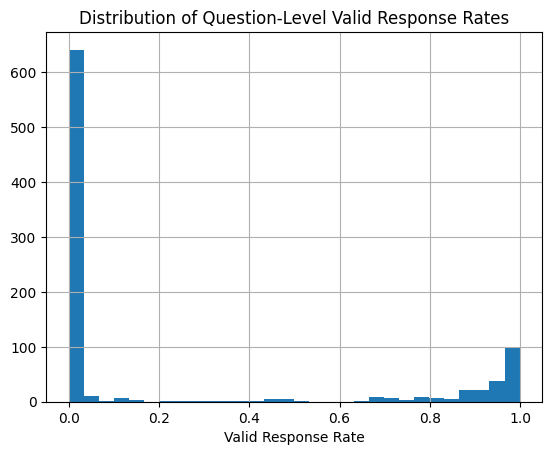

In [20]:
valid_response_rate_df.mean(axis=0).hist(bins=30)
plt.xlabel("Valid Response Rate")
plt.title("Distribution of Question-Level Valid Response Rates")
plt.show()


In [21]:
# mean across questions → one value per question
q_mean = valid_response_rate_df.mean(axis=0)

In [22]:
q_mean

A001    0.998401
A002    0.996741
A003    0.994358
A004    0.988824
A005    0.988340
          ...   
H009    0.915593
H010    0.903916
H011    0.908218
I001    0.942286
I002    0.958329
Length: 904, dtype: float64

In [23]:
q_mean_sorted = q_mean.sort_values(ascending=True)


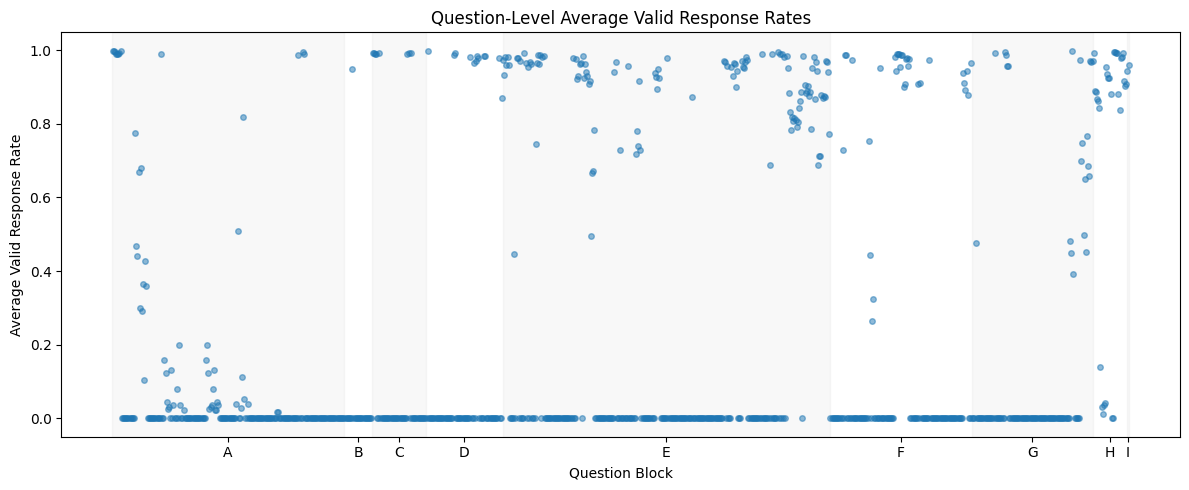

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure index is a Series we can work with
q_mean = q_mean.copy()

# Extract first letter (A–I)
groups = q_mean.index.to_series().str[0]

# Numeric x positions
x = range(len(q_mean))

plt.figure(figsize=(12, 5))
plt.plot(x, q_mean.values, marker='o', markersize = 4, linestyle='', alpha=0.5)

ax = plt.gca()

# --- Create blocks + centered tick labels ---
xticks = []
xtick_labels = []

start = 0


for i, (letter, idxs) in enumerate(groups.groupby(groups).groups.items()):
    end = start + len(idxs)

    if i % 2 == 0:
        ax.axvspan(
            start - 0.5, end - 0.5,
            color='gray',
            alpha=0.05,
            zorder=0
        )

    # Center tick for this block
    center = (start + end - 1) / 2
    xticks.append(center)
    xtick_labels.append(letter)

    start = end

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

plt.xlabel("Question Block")
plt.ylabel("Average Valid Response Rate")
plt.title("Question-Level Average Valid Response Rates")
plt.tight_layout()
plt.savefig("./question_level_valid_response_rate.png", dpi = 300)
plt.show()


### 6 Science and Technology Questions

In [25]:
sci_tech_codes = ['Q158', 'Q159', 'Q160', 'Q161', 'Q162', 'Q163']

In [26]:
for var in sci_tech_codes:
    df_data[var] = df_data[var].replace(invalid, np.nan)

##### Raw Distribution

In [27]:
long_df = df_data.melt(
    value_vars=sci_tech_codes,  # all Q columns
    var_name='item',                  # column for Q codes
    value_name='response'             # column for numeric response
)

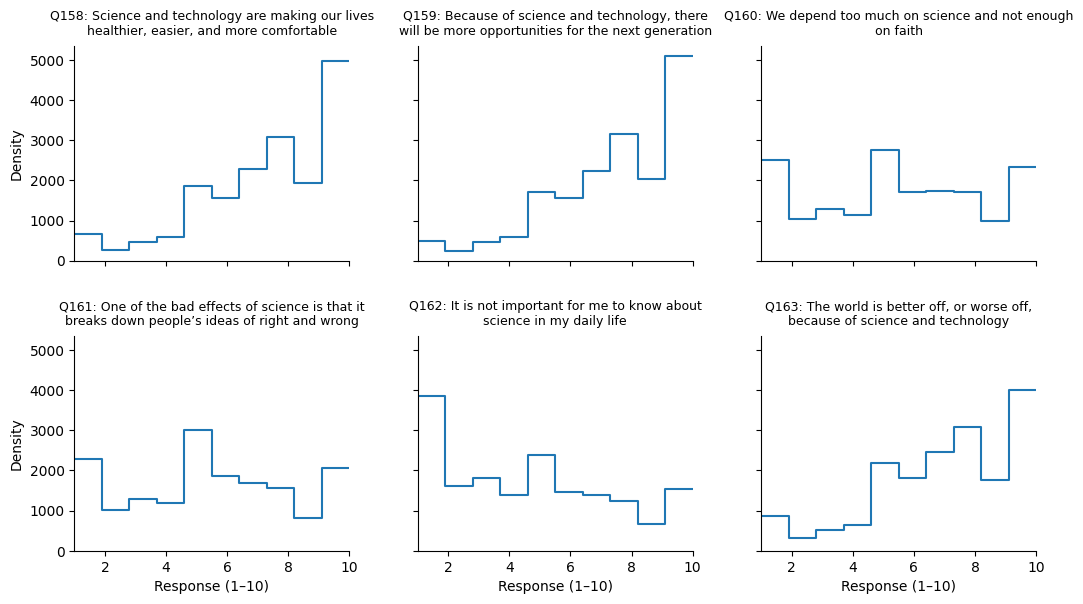

In [28]:
# Auto wrap function (wrap at ~50 chars)
import textwrap

def wrap_text(s, width=50):
    return "\n".join(textwrap.wrap(s, width))

long_df['wrapped_label'] = long_df['item'].map(
    lambda x: wrap_text(x + ": " + question_text.get(x, x), width=50)
)

g = sns.displot(
    data=long_df,
    x='response',
    col='wrapped_label',
    col_wrap=3,
    bins=10,
    binrange=(1,10),
    stat='frequency',
    element='step',
    fill=False,
    height=3.2,
    aspect=1.1
)

g.set(xlim=(1, 10))
g.set_axis_labels("Response (1–10)", "Density")

# Adjust title font/spacing
g.set_titles("{col_name}", size=9, pad=8)
g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)

g.savefig(
    "./science_tech_attitude_real_data_hist_faceted_fixedx.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


#### Correlation

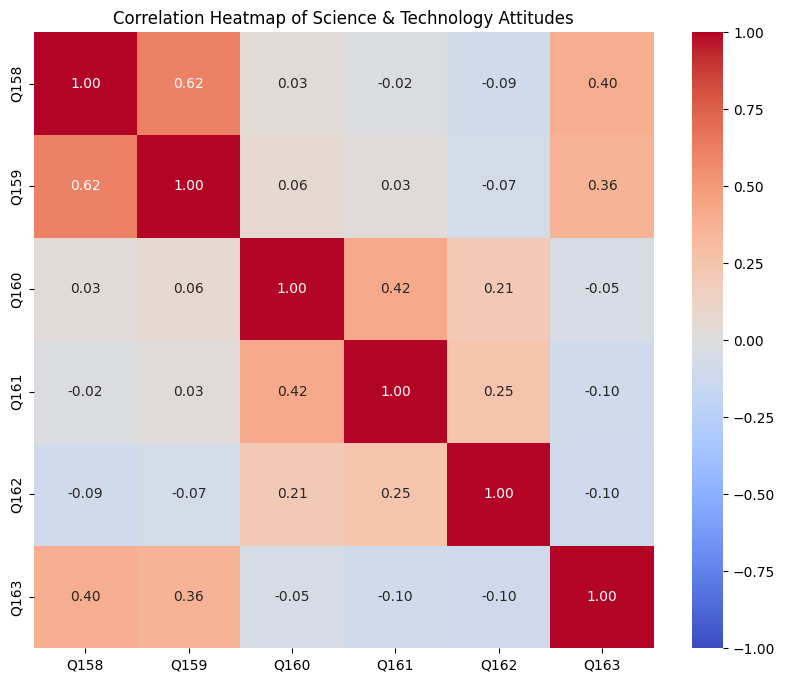

In [29]:
correlation_matrix = df_data[sci_tech_codes].dropna().corr()
plt.figure(figsize=(10, 8)) # Optional: Adjust the size of the plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin = -1, vmax = 1, fmt=".2f")
plt.title('Correlation Heatmap of Science & Technology Attitudes')
plt.savefig('./sci_tech_attitude_heatmap.png', dpi = 300, bbox_inches="tight")
plt.show()


#### Reverse Code for Attitude Direction Consistency

In [30]:
questions_to_reverse = ['Q160', 'Q161', 'Q162']

In [31]:
for q in questions_to_reverse:
    df_data[questions_to_reverse] = 11 - df_data[questions_to_reverse]

#### One Composite Variable For Science & Technology Attitude

In [32]:
df_data['sci_tech_attitude'] = df_data[sci_tech_codes].mean(axis=1, skipna=False)
df_data

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q284,Q285,Q286,Q287,Q288,Q289,Q290,X003R,Country,sci_tech_attitude
0,1,1,1,3,1,4,1,1,2,1,...,2,2,3,3,5,1,20001,5,Andorra,6.333333
1,1,1,1,4,1,4,1,2,1,1,...,2,1,1,2,9,1,20001,4,Andorra,8.000000
2,1,2,2,2,3,3,2,1,2,1,...,2,1,2,3,5,1,20001,4,Andorra,5.333333
3,1,1,1,4,2,4,1,2,2,1,...,2,2,2,4,4,0,20001,5,Andorra,6.333333
4,1,1,1,3,1,3,1,2,1,1,...,2,1,1,4,4,0,20001,4,Andorra,6.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,1,3,1,1,1,2,1,2,1,2,...,-3,2,2,3,5,1,716006,3,Zimbabwe,5.166667
97216,1,1,2,1,1,1,1,2,1,2,...,3,1,1,2,5,2,716007,2,Zimbabwe,10.000000
97217,1,3,2,2,2,2,1,2,1,2,...,2,2,2,4,5,1,716006,1,Zimbabwe,8.500000
97218,1,2,2,1,1,1,1,1,1,2,...,2,1,2,4,1,1,716006,4,Zimbabwe,8.500000


In [33]:
df_data['sci_tech_attitude'].describe()

count    89543.000000
mean         6.589838
std          1.469450
min          1.000000
25%          5.500000
50%          6.500000
75%          7.500000
max         10.000000
Name: sci_tech_attitude, dtype: float64

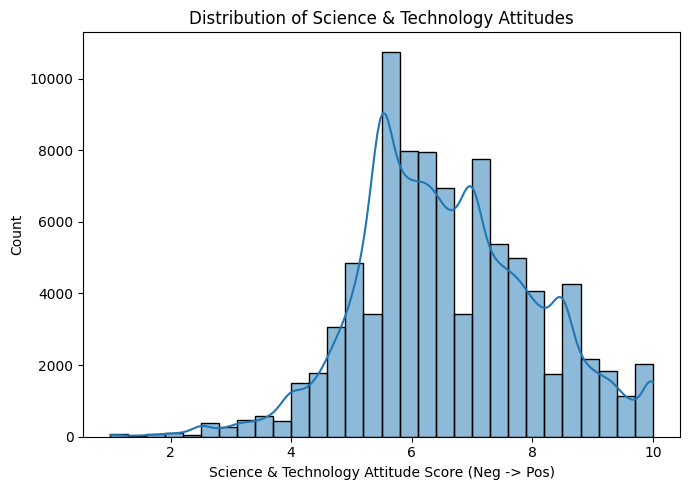

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.histplot(
    data=df_data,
    x='sci_tech_attitude',
    bins=30,                 # good resolution for composite scores
    kde=True                 # optional density curve
)

plt.xlabel('Science & Technology Attitude Score (Neg -> Pos)')
plt.ylabel('Count')
plt.title('Distribution of Science & Technology Attitudes', fontsize=12)

plt.tight_layout()
plt.savefig('./sci_tech_attitude_dist.png', dpi=300, bbox_inches="tight")
plt.show()

#### Robustness

In [100]:
df_data['Q44'].value_counts()

Q44
 1    66396
 2    20021
 3     8740
-1     1541
-2      333
-5      189
Name: count, dtype: int64

In [101]:
df_data['Q44'].loc[df_data['Q44'] < 0] = np.nan
df_data['tech_emphasis'] = df_data['Q44']

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/2136811266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['Q44'].loc[df_data['Q44'] < 0] = np.nan


### Morality

In [35]:
morality_codes = [f'Q{i}' for i in range(177, 196)]
morality_codes

['Q177',
 'Q178',
 'Q179',
 'Q180',
 'Q181',
 'Q182',
 'Q183',
 'Q184',
 'Q185',
 'Q186',
 'Q187',
 'Q188',
 'Q189',
 'Q190',
 'Q191',
 'Q192',
 'Q193',
 'Q194',
 'Q195']

#### Exploratory Factor Analysis

In [36]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

In [37]:
for var in morality_codes:
    df_data[var] = df_data[var].replace(invalid, np.nan)

morality_df = df_data[morality_codes].dropna()

In [38]:
morality_df.shape

(73353, 19)

In [39]:
morality_df.describe()

,Q177,Q178,Q179,Q180,Q181,Q182,Q183,Q184,Q185,Q186,Q187,Q188,Q189,Q190,Q191,Q192,Q193,Q194,Q195
count,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.000000,73353.00000,73353.000000,73353.000000
mean,3.035486,2.842092,1.861478,2.244557,2.007021,4.095824,3.062192,3.576923,5.002986,4.746582,2.648671,3.973812,1.842310,2.935367,1.996224,1.830136,3.55237,2.035350,4.055867
std,2.690462,2.561683,1.836562,2.148193,1.952321,3.382755,2.687322,2.985875,3.202261,3.403689,2.467382,3.178473,1.871233,2.599515,1.894587,1.835724,3.02824,1.955754,3.159269
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
50%,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000,5.000000,5.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,2.00000,1.000000,3.000000
75%,5.000000,4.000000,2.000000,3.000000,2.000000,7.000000,5.000000,5.000000,8.000000,8.000000,4.000000,6.000000,2.000000,5.000000,2.000000,2.000000,5.00000,2.000000,6.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000


In [40]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = StandardScaler().fit_transform(morality_df)

corr = np.corrcoef(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(corr)

print(eigenvalues)

[6.95312394 3.42405113 1.20042505 0.92433421 0.7336437  0.62773409
 0.60236747 0.51079524 0.48445862 0.45904693 0.26103895 0.4073414
 0.30543497 0.31328675 0.3232312  0.38298468 0.38064552 0.34671642
 0.35933977]


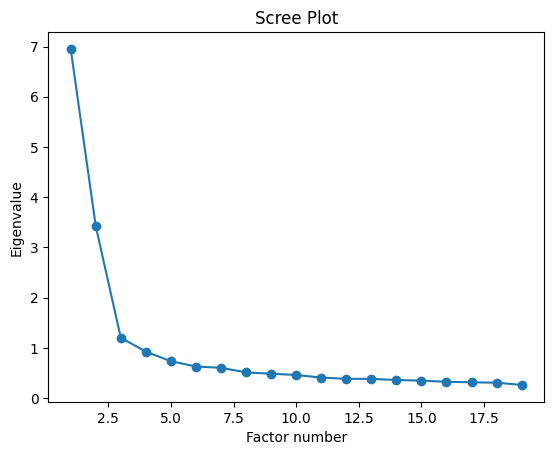

In [41]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(eigenvalues)+1), sorted(eigenvalues, reverse=True), marker='o')
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

In [42]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

In [43]:
# standardize
scaler = StandardScaler()
X = scaler.fit_transform(morality_df)

n, p = X.shape

In [44]:
corr_matrix = np.corrcoef(X, rowvar=False)
real_eigenvalues = np.linalg.eigvals(corr_matrix)

real_eigenvalues = np.sort(real_eigenvalues)[::-1]

In [45]:
n_iter = 500
random_eigenvalues = np.zeros((n_iter, p))

for i in range(n_iter):
    
    random_data = np.random.normal(size=(n, p))
    
    random_corr = np.corrcoef(random_data, rowvar=False)
    
    random_eigenvalues[i,:] = np.linalg.eigvals(random_corr)

# mean random eigenvalues
mean_random_eigenvalues = random_eigenvalues.mean(axis=0)

mean_random_eigenvalues = np.sort(mean_random_eigenvalues)[::-1]

In [46]:
results = pd.DataFrame({
    "Factor": range(1,p+1),
    "Real Eigenvalue": real_eigenvalues,
    "Random Eigenvalue": mean_random_eigenvalues
})

print(results)

    Factor  Real Eigenvalue  Random Eigenvalue
0        1         6.953124           1.001424
1        2         3.424051           1.000990
2        3         1.200425           1.000332
3        4         0.924334           1.000302
4        5         0.733644           1.000169
5        6         0.627734           1.000138
6        7         0.602367           1.000020
7        8         0.510795           0.999998
8        9         0.484459           0.999915
9       10         0.459047           0.999915
10      11         0.407341           0.999812
11      12         0.382985           0.999794
12      13         0.380646           0.999781
13      14         0.359340           0.999767
14      15         0.346716           0.999673
15      16         0.323231           0.999651
16      17         0.313287           0.999620
17      18         0.305435           0.999425
18      19         0.261039           0.999274


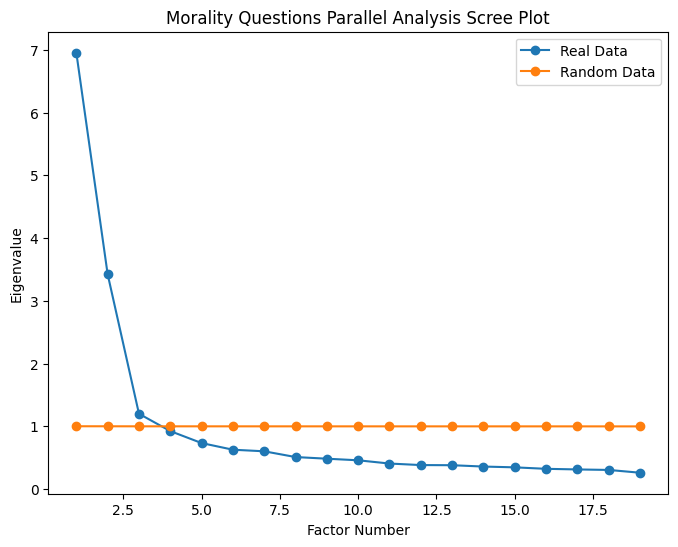

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(range(1,p+1), real_eigenvalues, marker='o', label="Real Data")
plt.plot(range(1,p+1), mean_random_eigenvalues, marker='o', label="Random Data")

plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Morality Questions Parallel Analysis Scree Plot")
plt.savefig('./morality_parallel_analysis_scree_plot.png', dpi = 300, bbox_inches="tight")
plt.legend()

plt.show()

In [48]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(morality_df)

loadings = pd.DataFrame(
    fa.loadings_,
    index=morality_codes,
    columns=["purity_morality", "violence_morality", "civic_morality"]
)

print(loadings)

      purity_morality  violence_morality  civic_morality
Q177        -0.004319           0.175677        0.545116
Q178         0.127006           0.146972        0.643521
Q179         0.134967           0.465623        0.626029
Q180         0.159879           0.346158        0.649278
Q181         0.138727           0.465050        0.610919
Q182         0.793577           0.001038        0.089559
Q183         0.691044           0.195699        0.245493
Q184         0.779435           0.122366        0.099199
Q185         0.744283           0.027064        0.000928
Q186         0.825658          -0.024302        0.045088
Q187         0.590789           0.351026        0.194297
Q188         0.680311           0.174402        0.003093
Q189         0.083317           0.725629        0.315616
Q190         0.004167           0.491814        0.129966
Q191         0.177517           0.734098        0.327492
Q192         0.105928           0.691269        0.388892
Q193         0.717370          

/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [49]:
question_labels = {
    "Q177": "Benefits fraud",
    "Q178": "Fare evasion",
    "Q179": "Stealing",
    "Q180": "Tax cheating",
    "Q181": "Bribery",

    "Q182": "Homosexuality",
    "Q183": "Prostitution",
    "Q184": "Abortion",
    "Q185": "Divorce",
    "Q186": "Premarital sex",
    "Q187": "Suicide",
    "Q188": "Euthanasia",
    "Q193": "Casual sex",

    "Q189": "Wife beating",
    "Q190": "Child beating",
    "Q191": "Violence against others",
    "Q192": "Terrorism",
    "Q194": "Political violence",
    "Q195": "Death penalty"
}

loadings.index = loadings.index.map(question_labels)

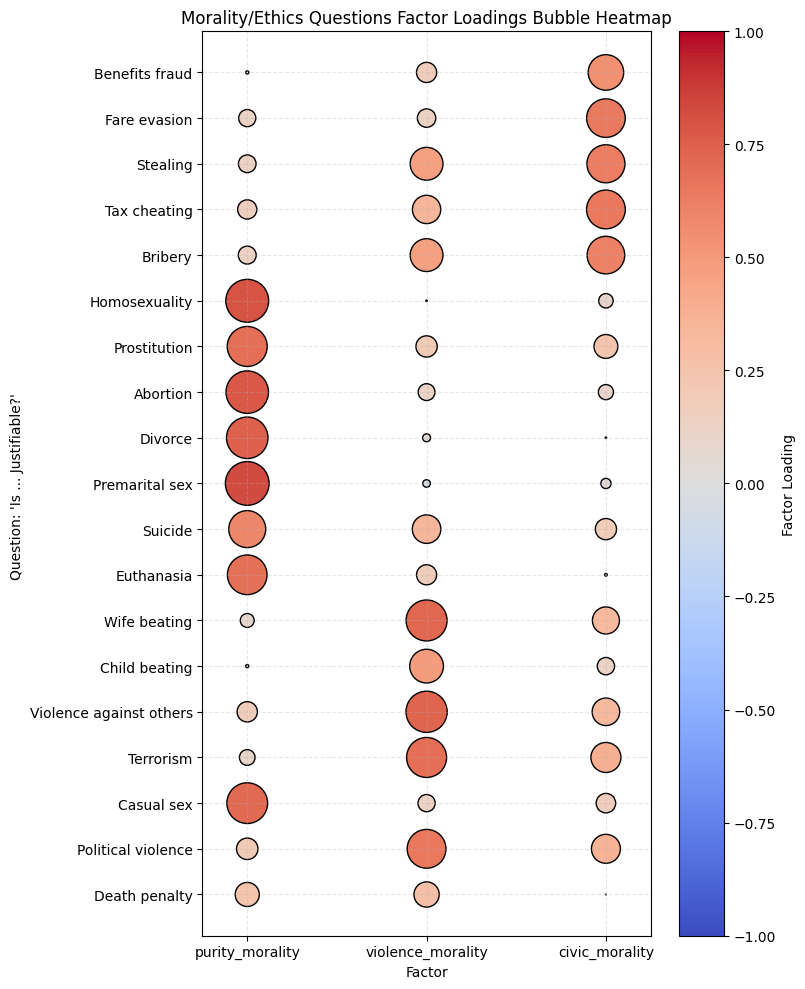

In [50]:
# Your loadings DataFrame
loadings = loadings.copy()

# Convert to long format
long_df = loadings.reset_index().melt(
    id_vars='index',
    var_name='Factor',
    value_name='Loading'
).rename(columns={'index': 'Question'})

# Create numeric positions
x_labels = loadings.columns
y_labels = loadings.index

x_map = {label: i for i, label in enumerate(x_labels)}
y_map = {label: i for i, label in enumerate(y_labels)}

long_df['x'] = long_df['Factor'].map(x_map)
long_df['y'] = long_df['Question'].map(y_map)

# Plot
plt.figure(figsize=(8,10))

scatter = plt.scatter(
    long_df['x'],
    long_df['y'],
    s=np.abs(long_df['Loading']) * 1200,   # size = magnitude
    c=long_df['Loading'],                  # color = signed value
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    edgecolors='black'
)

plt.xticks(range(len(x_labels)), x_labels)
plt.xlim(-0.25, len(x_labels) - 0.75)
plt.yticks(range(len(y_labels)), y_labels)
plt.gca().invert_yaxis()

plt.colorbar(scatter, label='Factor Loading')
plt.title("Morality/Ethics Questions Factor Loadings Bubble Heatmap")
plt.xlabel("Factor")
plt.ylabel("Question: 'Is ... Justifiable?' ")

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('./factor_loadings_morality.png', dpi = 300, bbox_inches="tight")
plt.show()

In [51]:
factor_scores = fa.transform(morality_df)

df_data["purity_morality"] = np.nan
df_data["civic_morality"] = np.nan
df_data["violence_morality"] = np.nan

df_data.loc[morality_df.index, "purity_morality"] = -factor_scores[:,0] # note, reversed value
df_data.loc[morality_df.index, "civic_morality"] = -factor_scores[:,1]
df_data.loc[morality_df.index, "violence_morality"] = -factor_scores[:,2]

/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [52]:
df_data

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q287,Q288,Q289,Q290,X003R,Country,sci_tech_attitude,purity_morality,civic_morality,violence_morality
0,1,1,1,3,1,4,1,1,2,1,...,3,5,1,20001,5,Andorra,6.333333,0.355346,0.504568,0.447055
1,1,1,1,4,1,4,1,2,1,1,...,2,9,1,20001,4,Andorra,8.000000,-1.550227,0.725157,0.725040
2,1,2,2,2,3,3,2,1,2,1,...,3,5,1,20001,4,Andorra,5.333333,-1.085563,0.348778,0.701385
3,1,1,1,4,2,4,1,2,2,1,...,4,4,0,20001,5,Andorra,6.333333,-1.031371,0.722903,0.503202
4,1,1,1,3,1,3,1,2,1,1,...,4,4,0,20001,4,Andorra,6.666667,-0.938215,0.725889,0.508664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,1,3,1,1,1,2,1,2,1,2,...,3,5,1,716006,3,Zimbabwe,5.166667,1.129937,0.481986,-0.283253
97216,1,1,2,1,1,1,1,2,1,2,...,2,5,2,716007,2,Zimbabwe,10.000000,0.800756,0.004200,0.698764
97217,1,3,2,2,2,2,1,2,1,2,...,4,5,1,716006,1,Zimbabwe,8.500000,1.077234,0.319399,0.425317
97218,1,2,2,1,1,1,1,1,1,2,...,4,1,1,716006,4,Zimbabwe,8.500000,1.077234,0.319399,0.425317


In [53]:
print("Total rows:", len(df_data))

print("Valid morality rows:", df_data["purity_morality"].notna().sum())

Total rows: 97220
Valid morality rows: 73353


**Factor 1: Purity Morality**  
Higher 'purity_morality' score = thinks these are LESS justifiable
* → More traditional/restrictive
* → Less permissive about sex, abortion, euthanasia
* → Conservative/religious orientation

**Factor 2: Civic Morality**  
Higher 'civic_morality' score = thinks these items are LESS justifiable
* → Stronger civic norms
* → Less tolerant of civic violations (fraud, theft, bribes)

**Factor 3: Violence Morality**  
Higher 'violence_morality' score = thinks these items are Less justifiable
* → Less accepting of violence/use of physical force
* → Anti-violence orientation

### Trust in University(Higher Education Institution)

In [54]:
df_data['Q75']

0        1
1        2
2        2
3       -2
4       -2
        ..
97215    1
97216    3
97217    2
97218    2
97219    3
Name: Q75, Length: 97220, dtype: int64

In [55]:
df_data['trust_university'] = df_data['Q75'].replace(invalid, np.nan)

In [56]:
print("Total rows:", len(df_data))

print("Valid Trust rows:", df_data["trust_university"].notna().sum())

Total rows: 97220
Valid Trust rows: 93295


/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/1122635463.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


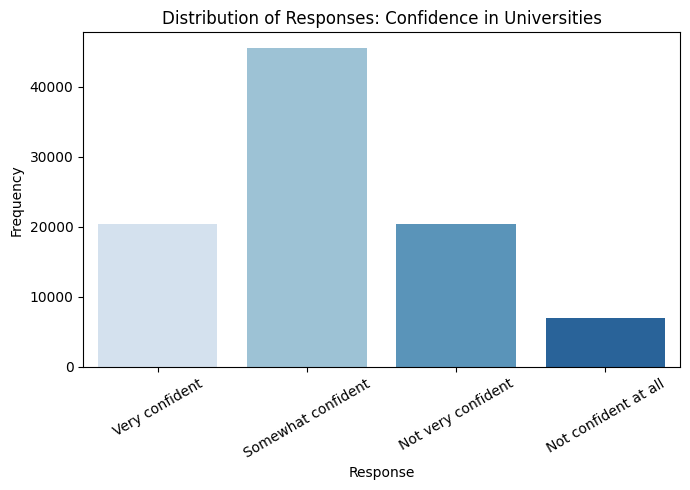

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: map codes to readable labels if available
option_labels = {
    1: 'Very confident',
    2: 'Somewhat confident',
    3: 'Not very confident',
    4: 'Not confident at all'
}

# Count frequency of each response
counts = df_data['trust_university'].value_counts().sort_index()

# Plot
plt.figure(figsize=(7,5))
sns.barplot(
    x=[option_labels.get(k, k) for k in counts.index],
    y=counts.values,
    palette='Blues'
)

plt.xlabel('Response')
plt.ylabel('Frequency')
plt.title('Distribution of Responses: Confidence in Universities', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./uni_attitude_dist.png', dpi = 300, bbox_inches="tight")
plt.show()

I then reverse the coding so higher value indicates more confidence in universities. 

In [58]:
df_data['trust_university'] =  5 - df_data['trust_university']

Now, 4=Very confident, 3=Somewhat, 2=Not very, 1=Not at all

### Age Groups

I found a binned versino of age with the following response scale:  
1.- 16-24 years
2.- 25-34 years
3.- 35-44 years
4.- 45-54 years
5.- 55-64 years
6.- 65 and over
-1-. - Don't know
-2-.- No answer
-4-.- Not asked
-5-.- Missing; Not available; AU: Other

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/1285074396.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_data['X003R'].loc[df_data['X003R'] < 0] = np.nan
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26

Text(0.5, 1.0, 'Distribution of Age Interval Responses')

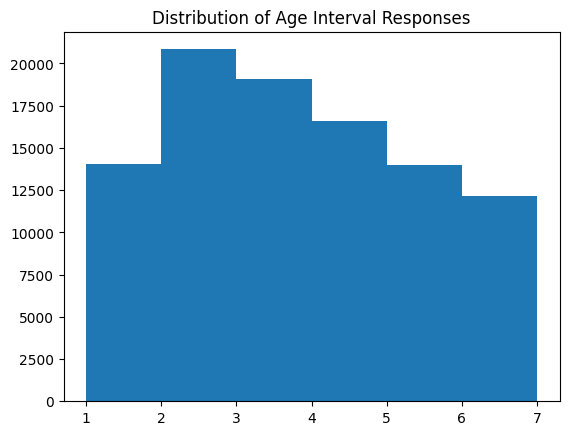

In [59]:
df_data['X003R']
df_data['X003R'].loc[df_data['X003R'] < 0] = np.nan
plt.hist(df_data['X003R'], bins = [1, 2, 3, 4, 5, 6, 7])
plt.title("Distribution of Age Interval Responses")

In [60]:
df_data['age'] = df_data['X003R']

### Sex

In [61]:
df_data['Q260']
df_data['Q260'].loc[df_data['Q260'] < 0] = np.nan
df_data['Q260'].loc[df_data['Q260'] == 2] = 0

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/314857796.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_data['Q260'].loc[df_data['Q260'] < 0] = np.nan
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538

Recode 'female' response from 2 to 0
Now, female = 0, male = 1.

In [62]:
df_data['sex'] = df_data['Q260']

### Filtering by Country Sample Sizes

#### Main

In [63]:
# Keep only rows with complete data on all 5 key variables
key_vars = [
    'sci_tech_attitude',
    'trust_university', 
    'purity_morality',
    'civic_morality',
    'violence_morality',
    'age',
    'sex'
]

df_complete = df_data[['Country'] + sci_tech_codes + key_vars].dropna()

print(f"Original N: {len(df_data)}")
print(f"Complete cases N: {len(df_complete)}")
print(f"Dropped {len(df_data) - len(df_complete)} rows ({100*(len(df_data) - len(df_complete))/len(df_data):.1f}%)")


Original N: 97220
Complete cases N: 67658
Dropped 29562 rows (30.4%)


In [64]:
# Count by country
country_counts = df_complete.groupby('Country').size().reset_index(name='N')
country_counts = country_counts.sort_values('N', ascending=False)

print(f"\nTotal countries: {len(country_counts)}")
print(f"Countries with N >= 200: {(country_counts['N'] >= 200).sum()}")
print(f"Countries with N < 200: {(country_counts['N'] < 200).sum()}")

# Show smallest samples
print("\nCountries with smallest samples:")
print(country_counts.tail(10))


Total countries: 55
Countries with N >= 200: 55
Countries with N < 200: 0

Countries with smallest samples:
        Country    N
22   Kazakhstan  859
26        Macao  757
8         Chile  738
21        Japan  729
52      Uruguay  683
1     Argentina  662
34  New Zealand  659
50      Ukraine  514
25        Libya  511
11       Cyprus  359


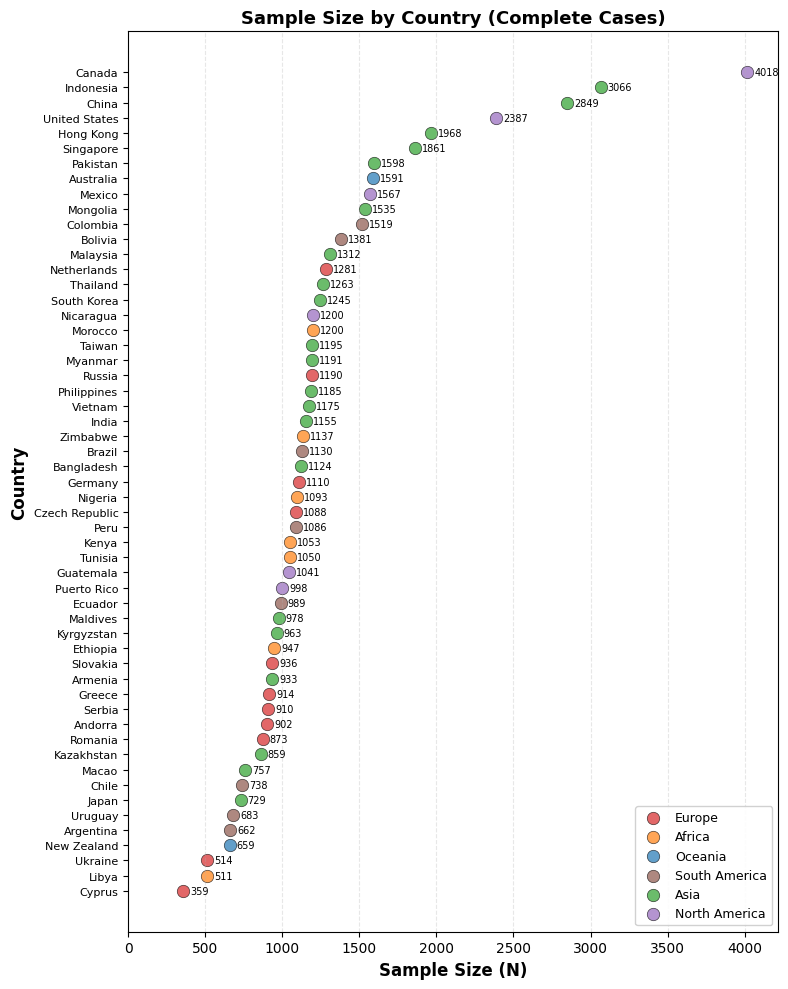

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/979410470.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=10)


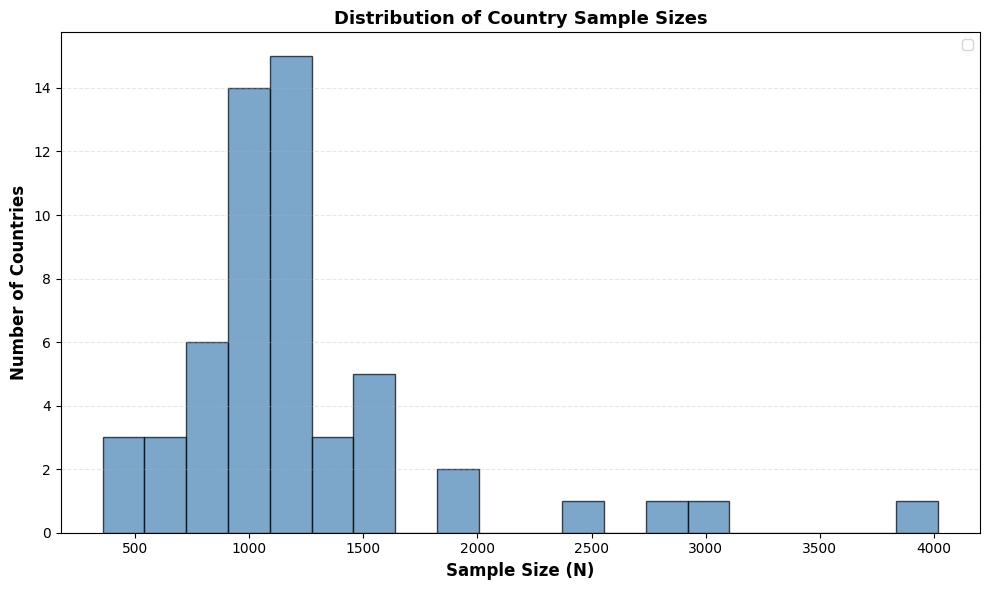


SAMPLE SIZE SUMMARY BY CONTINENT
               # Countries        Avg N  Min N  Max N  Total N
Continent                                                     
Asia                    21  1378.142857    729   3066    28941
Europe                  11   916.090909    359   1281    10077
South America            8  1023.500000    662   1519     8188
Africa                   7   998.714286    511   1200     6991
North America            6  1868.500000    998   4018    11211
Oceania                  2  1125.000000    659   1591     2250


In [65]:
# Visualization
fig, ax1 = plt.subplots(figsize=(8, 10))

# ============================================================================
# Plot 1: Scatter plot with continent colors
# ============================================================================

# Add continent information
country_counts['Continent'] = country_counts['Country'].map(ctry2continent)

# Sort by sample size for y-axis ordering
country_counts_sorted = country_counts.sort_values('N', ascending=True)

# Create y-positions
y_positions = range(len(country_counts_sorted))

# Plot scatter points colored by continent
for continent in country_counts_sorted['Continent'].unique():
    mask = country_counts_sorted['Continent'] == continent
    subset = country_counts_sorted[mask]
    y_subset = [y_positions[i] for i, idx in enumerate(country_counts_sorted.index) if idx in subset.index]
    
    ax1.scatter(
        subset['N'], 
        y_subset,
        s=80,
        alpha=0.7,
        label=continent,
        color=continent_colors.get(continent, 'gray'),
        edgecolors='black',
        linewidth=0.5
    )

# Add sample size text labels
for i, (idx, row) in enumerate(country_counts_sorted.iterrows()):
    ax1.text(
        row['N'] + 45,  # offset to the right
        i,
        str(row['N']),
        fontsize=7,
        va='center',
        ha='left'
    )

# Formatting
ax1.set_yticks(y_positions)
ax1.set_yticklabels(country_counts_sorted['Country'], fontsize=8)
ax1.set_xlabel('Sample Size (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Country', fontsize=12, fontweight='bold')
ax1.set_title('Sample Size by Country (Complete Cases)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_xlim(0, max(country_counts_sorted['N']) + 200)

plt.tight_layout()
plt.savefig('./country_sample_sizes_complete_cases.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Plot 2: Histogram (unchanged)
# ============================================================================
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.hist(country_counts['N'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax2.set_xlabel('Sample Size (N)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Countries', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Country Sample Sizes', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./country_sample_sizes_complete_cases_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary by continent
print("\n" + "="*60)
print("SAMPLE SIZE SUMMARY BY CONTINENT")
print("="*60)
continent_summary = country_counts.groupby('Continent').agg({
    'N': ['count', 'mean', 'min', 'max', 'sum']
})
continent_summary.columns = ['# Countries', 'Avg N', 'Min N', 'Max N', 'Total N']
print(continent_summary.sort_values('# Countries', ascending=False))


In [66]:
valid_countries = country_counts[country_counts['N'] >= 200]['Country'].values
df_filtered = df_complete[df_complete['Country'].isin(valid_countries)]

print(f"\n{'='*60}")
print(f"AFTER FILTERING TO N >= 200:")
print(f"{'='*60}")
print(f"Countries retained: {len(valid_countries)}")
print(f"Countries dropped: {len(country_counts) - len(valid_countries)}")
print(f"Total N: {len(df_filtered)}")
print(f"Average N per country: {len(df_filtered)/len(valid_countries):.0f}")



AFTER FILTERING TO N >= 200:
Countries retained: 55
Countries dropped: 0
Total N: 67658
Average N per country: 1230


In [67]:
df_filtered.iloc[:,7:].corr()

,sci_tech_attitude,trust_university,purity_morality,civic_morality,violence_morality,age,sex
sci_tech_attitude,1.000000,0.139442,-0.156519,0.112644,0.175965,0.005783,0.044944
trust_university,0.139442,1.000000,0.011680,0.048101,0.064419,0.009498,0.007936
purity_morality,-0.156519,0.011680,1.000000,0.017623,0.028283,-0.049154,-0.005645
civic_morality,0.112644,0.048101,0.017623,1.000000,0.234335,0.083892,-0.055084
violence_morality,0.175965,0.064419,0.028283,0.234335,1.000000,0.128959,-0.018387
age,0.005783,0.009498,-0.049154,0.083892,0.128959,1.000000,0.023743
sex,0.044944,0.007936,-0.005645,-0.055084,-0.018387,0.023743,1.000000


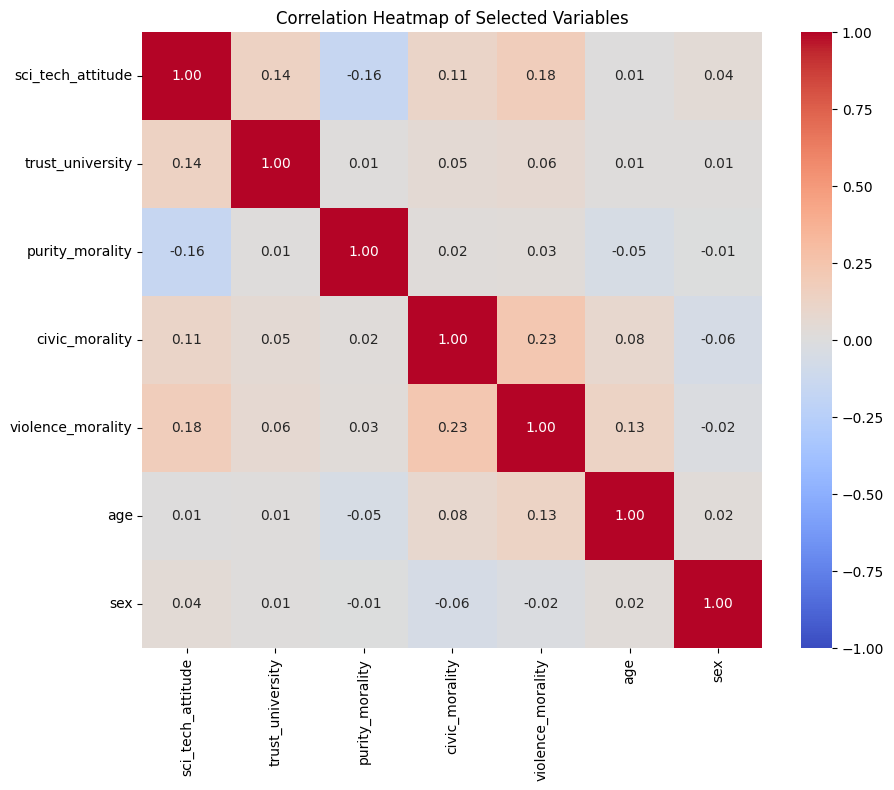

In [68]:
plt.figure(figsize=(10, 8)) # Optional: Adjust the size of the plot
sns.heatmap(df_filtered.iloc[:,7:].corr(), annot=True, cmap='coolwarm', vmin = -1, vmax = 1, fmt=".2f")
plt.title('Correlation Heatmap of Selected Variables')
plt.savefig('./heatmap.png', dpi = 300, bbox_inches="tight")
plt.show()


In [69]:
df_filtered.to_csv('./data/individual_level_analysis_data.csv', index=False)
print("\n✅ Datasets saved:")
print("   - ./data/individual_level_analysis_data.csv")


✅ Datasets saved:
   - ./data/individual_level_analysis_data.csv


#### Robustness

In [108]:
# Keep only rows with complete data on all 5 key variables
key_vars = [
    'tech_emphasis',
    'trust_university', 
    'purity_morality',
    'civic_morality',
    'violence_morality',
    'age',
    'sex'
]

df_robustness = df_data[['Country'] + key_vars].dropna()

print(f"Original N: {len(df_data)}")
print(f"Complete cases N: {len(df_robustness)}")
print(f"Dropped {len(df_data) - len(df_robustness)} rows ({100*(len(df_data) - len(df_robustness))/len(df_data):.1f}%)")


Original N: 97220
Complete cases N: 70568
Dropped 26652 rows (27.4%)


In [109]:
# Count by country
country_counts = df_robustness.groupby('Country').size().reset_index(name='N')
country_counts = country_counts.sort_values('N', ascending=False)

print(f"\nTotal countries: {len(country_counts)}")
print(f"Countries with N >= 200: {(country_counts['N'] >= 200).sum()}")
print(f"Countries with N < 200: {(country_counts['N'] < 200).sum()}")

# Show smallest samples
print("\nCountries with smallest samples:")
print(country_counts.tail(10))


Total countries: 56
Countries with N >= 200: 56
Countries with N < 200: 0

Countries with smallest samples:
        Country    N
0       Andorra  906
43       Serbia  902
22   Kazakhstan  878
26        Macao  775
8         Chile  759
52      Uruguay  703
1     Argentina  678
34  New Zealand  655
50      Ukraine  538
11       Cyprus  381


In [110]:
valid_countries = country_counts[country_counts['N'] >= 200]['Country'].values
df_filtered = df_robustness[df_robustness['Country'].isin(valid_countries)]

print(f"\n{'='*60}")
print(f"AFTER FILTERING TO N >= 200:")
print(f"{'='*60}")
print(f"Countries retained: {len(valid_countries)}")
print(f"Countries dropped: {len(country_counts) - len(valid_countries)}")
print(f"Total N: {len(df_filtered)}")
print(f"Average N per country: {len(df_filtered)/len(valid_countries):.0f}")



AFTER FILTERING TO N >= 200:
Countries retained: 56
Countries dropped: 0
Total N: 70568
Average N per country: 1260


In [111]:
df_filtered.to_csv('./data/robustness_analysis_data.csv', index=False)
print("\n✅ Datasets saved:")
print("   - ./data/robustness_analysis_data.csv")


✅ Datasets saved:
   - ./data/robustness_analysis_data.csv


### Context as Dispersion

In [70]:
country_agg = df_filtered.groupby('Country').agg({
    'sci_tech_attitude': ['mean', 'std', 'count'],
    'trust_university': ['mean', 'std'],
    'purity_morality': ['mean', 'std'],
    'civic_morality': ['mean', 'std'],
    'violence_morality': ['mean', 'std']
}).reset_index()


In [71]:
# Flatten multi-level column names
country_agg.columns = ['_'.join(col).strip('_') for col in country_agg.columns]


In [72]:
# Rename for clarity
country_agg = country_agg.rename(columns={
    'sci_tech_attitude_mean': 'sci_tech_mean',
    'sci_tech_attitude_std': 'sci_tech_std',
    'sci_tech_attitude_count': 'N',
    'trust_university_mean': 'trust_mean',
    'trust_university_std': 'trust_std',
    'purity_morality_mean': 'purity_mean',  
    'purity_morality_std': 'purity_std',
    'civic_morality_mean': 'civic_mean',
    'civic_morality_std': 'civic_std',
    'violence_morality_mean': 'violence_mean',
    'violence_morality_std': 'violence_std'
})


In [73]:
print(f"\n{'='*60}")
print(f"COUNTRY-LEVEL AGGREGATES (N={len(country_agg)} countries)")
print(f"{'='*60}")
print(country_agg.head(10))

print("\nDescriptive statistics of country-level variables:")
print(country_agg[['sci_tech_mean', 'sci_tech_std', 
                   'trust_mean', 'trust_std',
                   'purity_mean', 'purity_std']].describe())

# Save datasets for modeling
country_agg.to_csv('./data/country_level_analysis_data.csv', index=False)

print("\n✅ Datasets saved:")
print("   - ./data/country_level_analysis_data.csv")


COUNTRY-LEVEL AGGREGATES (N=55 countries)
      Country  sci_tech_mean  sci_tech_std     N  trust_mean  trust_std  \
0     Andorra       6.532520      1.440796   902    2.915743   0.665960   
1   Argentina       6.257049      1.281164   662    2.900302   0.773443   
2     Armenia       6.549482      1.371946   933    2.715970   0.861511   
3   Australia       7.326000      1.582723  1591    2.873036   0.656057   
4  Bangladesh       7.033660      1.146004  1124    3.358541   0.714004   
5     Bolivia       5.509655      1.241942  1381    2.643012   0.889962   
6      Brazil       6.536431      1.550792  1130    2.976991   0.857108   
7      Canada       7.049112      1.543828  4018    2.864111   0.731217   
8       Chile       5.844399      1.289852   738    2.807588   0.911764   
9       China       7.663976      1.162056  2849    3.193401   0.579506   

   purity_mean  purity_std  civic_mean  civic_std  violence_mean  violence_std  
0    -1.139666    0.850475    0.518724   0.443597 

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# 1. Load country-level data
# -----------------------------
country_agg = pd.read_csv('./data/country_level_analysis_data.csv')

# Select variables to visualize
mean_vars = ['purity_mean', 'civic_mean', 'violence_mean', 'trust_mean']
std_vars  = ['purity_std', 'civic_std', 'violence_std', 'trust_std']

# Optional: set country as index for easier plotting
country_agg.set_index('Country', inplace=True)


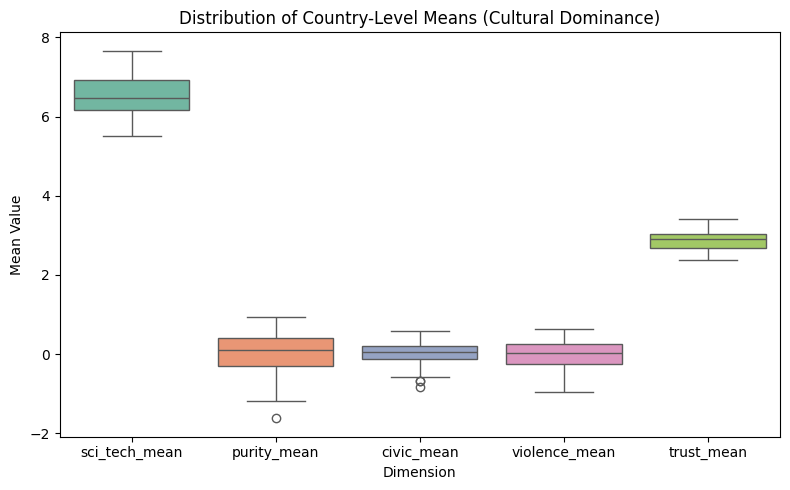

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(data=country_agg[['sci_tech_mean', 'purity_mean','civic_mean','violence_mean','trust_mean']], palette='Set2')
plt.title('Distribution of Country-Level Means (Cultural Dominance)')
plt.ylabel('Mean Value')
plt.xlabel('Dimension')
plt.tight_layout()
plt.show()

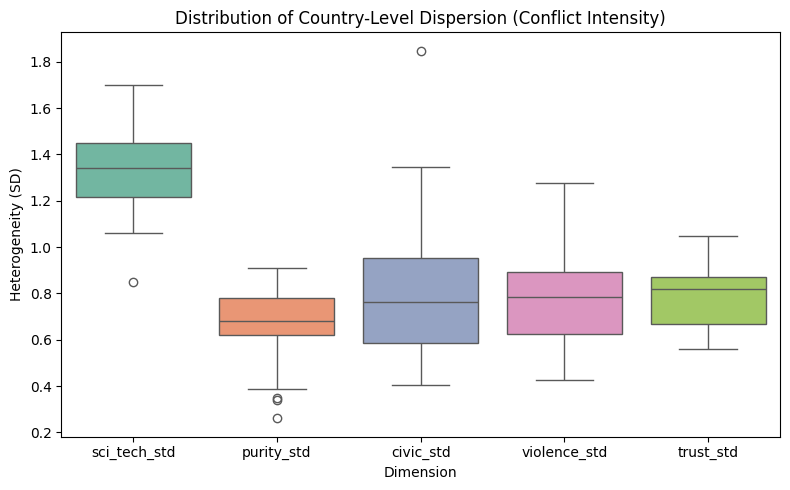

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(data=country_agg[['sci_tech_std', 'purity_std','civic_std','violence_std','trust_std']], palette='Set2')
plt.title('Distribution of Country-Level Dispersion (Conflict Intensity)')
plt.ylabel('Heterogeneity (SD)')
plt.xlabel('Dimension')
plt.tight_layout()
plt.show()

### REGRESSION ANALYSIS: COMPETING EXPLANATORY POWERS FRAMEWORK

In [77]:
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# Load data
df_individual = pd.read_csv('./data/individual_level_analysis_data.csv')
df_country = pd.read_csv('./data/country_level_analysis_data.csv')

print("="*80)
print("COMPETING EXPLANATORY POWERS: EMPIRICAL TESTS")
print("="*80)
print(f"Individual-level N: {len(df_individual):,}")
print(f"Countries: {df_individual['Country'].nunique()}")
print(f"Country-level N: {len(df_country)}")
print("="*80 + "\n")

COMPETING EXPLANATORY POWERS: EMPIRICAL TESTS
Individual-level N: 67,658
Countries: 55
Country-level N: 55



#### LEVEL 1: INDIVIDUAL POSITIONING (Within Countries)

##### **Individual Positioning Hypotheses**

**H1: Moral Allegiance Hypothesis**
> Individuals' allegiance to traditional moral authority depends on which moral domains are directly challenged by scientific explanatory power.

**Three dimensions with differential predictions:**

- **H1a (Purity Morality)**: Individuals with stronger purity moral concerns (sexual morality, bodily sanctity, life/death issues) express **less favorable** attitudes toward science and technology.
  - *Rationale*: Purity morality governs personal/bodily domains most directly challenged by science (biotech, reproductive technology, evolution, end-of-life medicine, sexuality)
  - *Prediction*: **Significant NEGATIVE effect**

- **H1b (Civic Morality)**: Individuals with stronger civic moral concerns (honesty, rule-following, social order) show **more supportive** in attitudes toward science and technology.
  - *Rationale*: Civic morality's relationship with science is theoretically ambiguous; it may indicate higher level of respect for order and tradition; it may also reflect modern society's civil rules which developed along with scientific traditions; science both challenges and reinforces civic norms However, the positive effect is stronger at the individual level.
  - *Prediction*: **Positive effect**

- **H1c (Violence Morality)**: Individuals with stronger anti-violence moral concerns express **more favorable** attitudes toward science and technology.
  - *Rationale*: Anti-violence people see science as progressive/beneficial.
  - *Prediction*: **Significant POSITIVE effect**

**Key Theoretical Point**: Not all moral domains compete equally with science. Civic morality's relationship with science is theoretically ambiguous due to its dual nature (traditional order vs. modern institutional rules), unlike purity and violence moralities where science's challenges are more direct

**H2: Institutional Legitimacy Hypothesis**
> Individuals who grant legitimacy to universities (new knowledge producers) express more favorable science attitudes, as they accept scientific authority.

**Interpretation**: Trust in universities = recognizing science's right to explain reality

| Hypothesis | Predictor → Outcome | Expected | Random Slopes? | Rationale |
|------------|---------------------|----------|----------------|-----------|
| **H1a** | Purity morality → Science attitudes | Negative | Yes | Direct competition |
| **H1b** | Civic morality → Science attitudes | Positive | Yes | Both Challenge & Reinforce |
| **H1c** | Violence morality → Science attitudes | Positive | Yes | Indirect competition |
| **H2** | Trust in universities → Science attitudes | Positive | Yes | Legitimacy acceptance |

##### Train-Test Split

Multiple Test Correction

When running m independent tests at a significance level of 
a (e.g., 0.05), the probability of at least one false positive is 1 - (1 - a)^m, which rapidly approaches 100% as m increases.

Neglecting correction leads to "fishing expeditions" or "p-hacking," where random, non-significant findings are interpreted as true.

In [78]:
# At the beginning of your Level 1 analysis, add:
from sklearn.model_selection import train_test_split

# Split your individual-level data (before Level 1 analysis)
# Stratify by country to maintain country representation
train_df, test_df = train_test_split(
    df_individual,  # your main dataframe
    test_size=0.40,  # 40% for testing, 60% for training
    random_state=42,  # for reproducibility
    stratify=df_individual['Country']  # maintains country proportions
)

print(f"Training set: {len(train_df)} observations")
print(f"Test set: {len(test_df)} observations")


Training set: 40594 observations
Test set: 27064 observations


##### MODEL 1.1: Random Intercepts ONLY (Baseline)

In [79]:
print("\n" + "="*80)
print("MODEL 1.1: RANDOM INTERCEPTS ONLY (Baseline)")
print("="*80 + "\n")

model_baseline = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university',
    data=train_df,
    groups=train_df['Country']
)
result_baseline = model_baseline.fit(method='lbfgs')
print(result_baseline.summary())

print(f"Log-Likelihood: {result_baseline.llf:.2f}")
print("\nFixed Effects:")
for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
    print(f"  {var:20s}: β = {result_baseline.params[var]:7.4f}, p = {result_baseline.pvalues[var]:.4f}")



MODEL 1.1: RANDOM INTERCEPTS ONLY (Baseline)

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sci_tech_attitude
No. Observations: 40594   Method:             REML             
No. Groups:       55      Scale:              1.7174           
Min. group size:  215     Log-Likelihood:     -68721.4062      
Max. group size:  2411    Converged:          Yes              
Mean group size:  738.1                                        
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            5.996    0.075  79.926 0.000  5.849  6.143
purity_morality     -0.375    0.010 -39.410 0.000 -0.394 -0.357
civic_morality       0.162    0.008  20.212 0.000  0.147  0.178
violence_morality    0.182    0.008  21.670 0.000  0.166  0.199
trust_university     0.176    0.008  21.227 0.000  0.160  0.192
Group 

/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [80]:
print("\n" + "="*80)
print("MODEL 1.1: RANDOM INTERCEPTS ONLY (Baseline)")
print("="*80 + "\n")

model_baseline = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university',
    data=test_df,
    groups=test_df['Country']
)
result_baseline = model_baseline.fit(method='lbfgs')
print(result_baseline.summary())

print(f"Log-Likelihood: {result_baseline.llf:.2f}")
print("\nFixed Effects:")
for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
    print(f"  {var:20s}: β = {result_baseline.params[var]:7.4f}, p = {result_baseline.pvalues[var]:.4f}")



MODEL 1.1: RANDOM INTERCEPTS ONLY (Baseline)



/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sci_tech_attitude
No. Observations: 27064   Method:             REML             
No. Groups:       55      Scale:              1.6854           
Min. group size:  144     Log-Likelihood:     -45598.0129      
Max. group size:  1607    Converged:          Yes              
Mean group size:  492.1                                        
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            5.954    0.077  77.442 0.000  5.803  6.105
purity_morality     -0.374    0.011 -32.631 0.000 -0.396 -0.351
civic_morality       0.179    0.010  18.352 0.000  0.160  0.198
violence_morality    0.188    0.010  18.225 0.000  0.167  0.208
trust_university     0.193    0.010  19.039 0.000  0.173  0.213
Group Var            0.274    0.041                  

##### MODEL 1.2: Random Slopes for PURITY + TRUST + VIOLENCE (FULL MODEL)

In [81]:
print("\n" + "="*80)
print("MODEL 1.2: RANDOM SLOPES FOR PURITY + TRUST + VIOLENCE (FULL MODEL)")
print("="*80 + "\n")

model_rs_full = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university',
    data=train_df,
    groups=train_df['Country'],
    re_formula='~purity_morality + trust_university + violence_morality + civic_morality'
)

try:
    result_rs_full = model_rs_full.fit(method='lbfgs', maxiter=500)
    print(result_rs_full.summary())
    
    print(f"Log-Likelihood: {result_rs_full.llf:.2f}")
    print(f"Improvement over Baseline Model: {result_rs_full.llf - result_baseline.llf:.2f}")
    
    print("\nFixed Effects (Average Across Countries):")
    print("-"*80)
    for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
        beta = result_rs_full.params[var]
        se = result_rs_full.bse[var]
        pval = result_rs_full.pvalues[var]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        print(f"  {var:20s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    full_model_converged = True
    best_model = result_rs_full
    best_model_name = "Full Random Slopes Model"
    
except Exception as e:
    print(f"⚠ Full model failed to converge: {e}")
    print("Using simpler configuration")
    full_model_converged = False
    result_rs_full = None
    best_model = result_baseline
    best_model_name = "Random Intercepts Only"



MODEL 1.2: RANDOM SLOPES FOR PURITY + TRUST + VIOLENCE (FULL MODEL)

                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sci_tech_attitude
No. Observations:         40594         Method:                   REML             
No. Groups:               55            Scale:                    1.6521           
Min. group size:          215           Log-Likelihood:           -68098.1279      
Max. group size:          2411          Converged:                Yes              
Mean group size:          738.1                                                    
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 5.916    0.091 64.980 0.000  5.738  6.095
purity_morality              

In [82]:
print("\n" + "="*80)
print("MODEL 1.2: RANDOM SLOPES FOR PURITY + TRUST + VIOLENCE (FULL MODEL)")
print("="*80 + "\n")

model_rs_full = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university',
    data=test_df,
    groups=test_df['Country'],
    re_formula='~purity_morality + trust_university + violence_morality + civic_morality'
)

try:
    result_rs_full = model_rs_full.fit(method='lbfgs', maxiter=500)
    print(result_rs_full.summary())
    
    print(f"Log-Likelihood: {result_rs_full.llf:.2f}")
    print(f"Improvement over Baseline Model: {result_rs_full.llf - result_baseline.llf:.2f}")
    
    print("\nFixed Effects (Average Across Countries):")
    print("-"*80)
    for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
        beta = result_rs_full.params[var]
        se = result_rs_full.bse[var]
        pval = result_rs_full.pvalues[var]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        print(f"  {var:20s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    full_model_converged = True
    best_model = result_rs_full
    best_model_name = "Full Random Slopes Model"
    
except Exception as e:
    print(f"⚠ Full model failed to converge: {e}")
    print("Using simpler configuration")
    full_model_converged = False
    result_rs_full = None
    best_model = result_baseline
    best_model_name = "Random Intercepts Only"



MODEL 1.2: RANDOM SLOPES FOR PURITY + TRUST + VIOLENCE (FULL MODEL)



/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sci_tech_attitude
No. Observations:         27064         Method:                   REML             
No. Groups:               55            Scale:                    1.6278           
Min. group size:          144           Log-Likelihood:           -45247.9136      
Max. group size:          1607          Converged:                Yes              
Mean group size:          492.1                                                    
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 5.861    0.089 66.187 0.000  5.687  6.034
purity_morality                          -0.283    0.036 -7.937 0.000 -0.353 -0.213
civic_morality 

In [83]:
print("\n" + "="*80)
print(f"COUNTRY-SPECIFIC EFFECTS: {best_model_name}")
print("="*80 + "\n")

random_effects = best_model.random_effects

# Determine which variables have random slopes
if full_model_converged:
    random_vars = ['purity_morality', 'trust_university', 'violence_morality', 'civic_morality']

    # Extract country-specific effects
    country_effects_data = []

    for country, effects in random_effects.items():
        country_data = {'Country': country}
        
        # Get random intercept
        if isinstance(effects, dict):
            random_intercept = effects.get('Group', 0)
            country_data['Random_Intercept'] = random_intercept
            country_data['Total_Intercept'] = best_model.params['Intercept'] + random_intercept
            # Get random slopes
            for var in random_vars:
                random_slope = effects.get(var, 0)
                fixed_effect = best_model.params[var]
                total_effect = fixed_effect + random_slope
                
                country_data[f'{var}_fixed'] = fixed_effect
                country_data[f'{var}_random'] = random_slope
                country_data[f'{var}_total'] = total_effect
        else:
            # Handle array-like effects (less common)
            country_data['Random_Intercept'] = effects[0] if len(effects) > 0 else 0
            country_data['Total_Intercept'] = best_model.params['Intercept'] + country_data['Random_Intercept']
            
            for i, var in enumerate(random_vars, start=1):
                if len(effects) > i:
                    random_slope = effects[i]
                    fixed_effect = best_model.params[var]
                    total_effect = fixed_effect + random_slope
                    
                    country_data[f'{var}_fixed'] = fixed_effect
                    country_data[f'{var}_random'] = random_slope
                    country_data[f'{var}_total'] = total_effect
        
        country_effects_data.append(country_data)

    country_effects_df = pd.DataFrame(country_effects_data)
            
    df_country['Continent'] = df_country['Country'].map(ctry2continent)
    # Merge with continent info
    country_effects_df = country_effects_df.merge(
        df_country[['Country', 'Continent', 'N']], 
        on='Country', 
        how='left'
    )

    # Display effects for each variable
    for var in random_vars:
        total_col = f'{var}_total'
        
        if total_col in country_effects_df.columns:
            print(f"\n{var.upper().replace('_', ' ')} EFFECTS:")
            print("-"*80)
            
            sorted_df = country_effects_df[['Country', total_col, 'Continent']].sort_values(total_col)
            
            print("\nMost Negative Effects (strongest resistance):")
            print(sorted_df.head(5).to_string(index=False))

            print("\nMost Positive Effects (least resistance / supportive):")
            print(sorted_df.tail(5).to_string(index=False))
            
            print(f"\nEffect Statistics:")
            print(f"  Mean: {country_effects_df[total_col].mean():.4f}")
            print(f"  SD: {country_effects_df[total_col].std():.4f}")
            print(f"  Range: [{country_effects_df[total_col].min():.4f}, {country_effects_df[total_col].max():.4f}]")



COUNTRY-SPECIFIC EFFECTS: Full Random Slopes Model


PURITY MORALITY EFFECTS:
--------------------------------------------------------------------------------

Most Negative Effects (strongest resistance):
      Country  purity_morality_total     Continent
United States              -0.789346 North America
       Canada              -0.719002 North America
  New Zealand              -0.661789       Oceania
      Romania              -0.641284        Europe
    Australia              -0.639302       Oceania

Most Positive Effects (least resistance / supportive):
   Country  purity_morality_total Continent
     Kenya               0.005375    Africa
   Myanmar               0.017835      Asia
     Libya               0.083369    Africa
Bangladesh               0.172850      Asia
 Indonesia               0.202891      Asia

Effect Statistics:
  Mean: -0.2828
  SD: 0.2213
  Range: [-0.7893, 0.2029]

TRUST UNIVERSITY EFFECTS:
----------------------------------------------------------------

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/869257749.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  country_data['Random_Intercept'] = effects[0] if len(effects) > 0 else 0
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/869257749.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  random_slope = effects[i]


In [84]:
print("\n" + "="*80)
print("HYPOTHESIS TESTING RESULTS")
print("="*80 + "\n")

hypotheses = [
    ('H1a: Purity → Science (negative)', 'purity_morality', 'negative'),
    ('H1b: Civic → Science (null)', 'civic_morality', 'null'),
    ('H1c: Violence → Science (positive)', 'violence_morality', 'positive'),
    ('H2: Trust → Science (positive)', 'trust_university', 'positive')
]

results = []
for hyp_name, var, expected in hypotheses:
    beta = best_model.params[var]
    pval = best_model.pvalues[var]
    
    if expected == 'null':
        supported = pval >= 0.05
        result = "✓ SUPPORTED" if supported else "✗ NOT SUPPORTED"
    elif expected == 'negative':
        supported = (pval < 0.05 and beta < 0)
        result = "✓ SUPPORTED" if supported else "✗ NOT SUPPORTED"
    else:  # positive
        supported = (pval < 0.05 and beta > 0)
        result = "✓ SUPPORTED" if supported else "✗ NOT SUPPORTED"
    
    results.append({
        'Hypothesis': hyp_name,
        'β': beta,
        'p-value': pval,
        'Expected': expected,
        'Result': result
    })
    
    print(f"{hyp_name:40s} β={beta:7.4f}, p={pval:.4f}  {result}")

results_df = pd.DataFrame(results)


HYPOTHESIS TESTING RESULTS

H1a: Purity → Science (negative)         β=-0.2828, p=0.0000  ✓ SUPPORTED
H1b: Civic → Science (null)              β= 0.1424, p=0.0000  ✗ NOT SUPPORTED
H1c: Violence → Science (positive)       β= 0.1736, p=0.0000  ✓ SUPPORTED
H2: Trust → Science (positive)           β= 0.1880, p=0.0000  ✓ SUPPORTED


##### MODEL 1.3: Demographic Control

In [118]:

# Fit Model 1.3: Model 1.2 + Demographic Controls
print("\nFitting Model 1.3...")
model_demo = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university + sex + age',
    data=train_df,
    groups=train_df['Country'],
    re_formula='~purity_morality + trust_university + violence_morality  + civic_morality'
)

try:
    result_demo = model_demo.fit(method='lbfgs', maxiter=500)
    print(result_demo.summary())
    
    print(f"\nLog-Likelihood: {result_demo.llf:.2f}")
    if 'result_rs_full' in locals() and result_rs_full is not None:
        print(f"Improvement over Model 1.2: {result_demo.llf - result_rs_full.llf:.2f}")
    
    print("\n" + "="*80)
    print("FIXED EFFECTS ESTIMATES")
    print("="*80)
    
    print("\nMain Predictors:")
    for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
        if var in result_demo.params:
            beta = result_demo.params[var]
            se = result_demo.bse[var]
            pval = result_demo.pvalues[var]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
            print(f"  {var:25s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    print("\nDemographic Controls:")
    demo_labels = {
        'female': 'Female (vs Male)',
        'age': 'Age '
    }
    for var, label in demo_labels.items():
        if var in result_demo.params:
            beta = result_demo.params[var]
            se = result_demo.bse[var]
            pval = result_demo.pvalues[var]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
            print(f"  {label:25s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    demo_model_converged = True
    best_model = result_demo
    best_model_name = "Full Random Slopes + Demographics Model"
    
    # Likelihood Ratio Test comparing Model 1.3 to Model 1.2
    if 'result_rs_full' in locals() and result_rs_full is not None:
        lr_stat = 2 * (result_demo.llf - result_rs_full.llf)
        df_diff = 4  # Added 4 demographic parameters
        from scipy.stats import chi2
        p_value = 1 - chi2.cdf(lr_stat, df_diff)
        
        print("\n" + "="*80)
        print("LIKELIHOOD RATIO TEST (Model 1.3 vs Model 1.2)")
        print("="*80)
        print(f"  LR statistic: {lr_stat:.2f}")
        print(f"  df: {df_diff}")
        print(f"  p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  → Demographic controls SIGNIFICANTLY improve model fit ✓")
        else:
            print("  → Demographic controls do NOT significantly improve model fit")
    
    print("\n" + "="*80)
    
except Exception as e:
    print(f"⚠ Model 1.3 convergence failed: {e}")
    import traceback
    traceback.print_exc()
    demo_model_converged = False
    result_demo = None


Fitting Model 1.3...
                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sci_tech_attitude
No. Observations:         40594         Method:                   REML             
No. Groups:               55            Scale:                    1.6441           
Min. group size:          215           Log-Likelihood:           -68006.5042      
Max. group size:          2411          Converged:                Yes              
Mean group size:          738.1                                                    
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 5.923    0.091 65.356 0.000  5.746  6.101
purity_morality                          -0.262    0.037 -7.141 0.000 -0.334 

In [119]:
print("\n" + "="*80)
print(f"COUNTRY-SPECIFIC EFFECTS: {best_model_name}")
print("="*80 + "\n")

random_effects = best_model.random_effects

# Determine which variables have random slopes
if full_model_converged:
    random_vars = ['purity_morality', 'trust_university', 'violence_morality', 'civic_morality']

    # Extract country-specific effects
    country_effects_data = []

    for country, effects in random_effects.items():
        country_data = {'Country': country}
        
        # Get random intercept
        if isinstance(effects, dict):
            random_intercept = effects.get('Group', 0)
            country_data['Random_Intercept'] = random_intercept
            country_data['Total_Intercept'] = best_model.params['Intercept'] + random_intercept
            # Get random slopes
            for var in random_vars:
                random_slope = effects.get(var, 0)
                fixed_effect = best_model.params[var]
                total_effect = fixed_effect + random_slope
                
                country_data[f'{var}_fixed'] = fixed_effect
                country_data[f'{var}_random'] = random_slope
                country_data[f'{var}_total'] = total_effect
        else:
            # Handle array-like effects (less common)
            country_data['Random_Intercept'] = effects[0] if len(effects) > 0 else 0
            country_data['Total_Intercept'] = best_model.params['Intercept'] + country_data['Random_Intercept']
            
            for i, var in enumerate(random_vars, start=1):
                if len(effects) > i:
                    random_slope = effects[i]
                    fixed_effect = best_model.params[var]
                    total_effect = fixed_effect + random_slope
                    
                    country_data[f'{var}_fixed'] = fixed_effect
                    country_data[f'{var}_random'] = random_slope
                    country_data[f'{var}_total'] = total_effect
        
        country_effects_data.append(country_data)

    country_effects_df = pd.DataFrame(country_effects_data)
            
    df_country['Continent'] = df_country['Country'].map(ctry2continent)
    # Merge with continent info
    country_effects_df = country_effects_df.merge(
        df_country[['Country', 'Continent', 'N']], 
        on='Country', 
        how='left'
    )

    # Display effects for each variable
    for var in random_vars:
        total_col = f'{var}_total'
        
        if total_col in country_effects_df.columns:
            print(f"\n{var.upper().replace('_', ' ')} EFFECTS:")
            print("-"*80)
            
            sorted_df = country_effects_df[['Country', total_col, 'Continent']].sort_values(total_col)
            
            print("\nMost Negative Effects (strongest resistance):")
            print(sorted_df.head(5).to_string(index=False))

            print("\nMost Positive Effects (least resistance / supportive):")
            print(sorted_df.tail(5).to_string(index=False))
            
            print(f"\nEffect Statistics:")
            print(f"  Mean: {country_effects_df[total_col].mean():.4f}")
            print(f"  SD: {country_effects_df[total_col].std():.4f}")
            print(f"  Range: [{country_effects_df[total_col].min():.4f}, {country_effects_df[total_col].max():.4f}]")



COUNTRY-SPECIFIC EFFECTS: Full Random Slopes + Demographics Model


PURITY MORALITY EFFECTS:
--------------------------------------------------------------------------------

Most Negative Effects (strongest resistance):
      Country  purity_morality_total     Continent
United States              -0.788939 North America
       Canada              -0.762628 North America
  Netherlands              -0.713917        Europe
  New Zealand              -0.659659       Oceania
      Romania              -0.652287        Europe

Most Positive Effects (least resistance / supportive):
   Country  purity_morality_total Continent
     Libya               0.038772    Africa
   Myanmar               0.043828      Asia
  Pakistan               0.133014      Asia
 Indonesia               0.146941      Asia
Bangladesh               0.450087      Asia

Effect Statistics:
  Mean: -0.2620
  SD: 0.2418
  Range: [-0.7889, 0.4501]

TRUST UNIVERSITY EFFECTS:
-------------------------------------------------

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/869257749.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  country_data['Random_Intercept'] = effects[0] if len(effects) > 0 else 0
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_26538/869257749.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  random_slope = effects[i]


In [86]:

# Fit Model 1.3: Model 1.2 + Demographic Controls
print("\nFitting Model 1.3...")
model_demo = MixedLM.from_formula(
    'sci_tech_attitude ~ purity_morality + civic_morality + violence_morality + trust_university + sex + age',
    data=test_df,
    groups=test_df['Country'],
    re_formula='~purity_morality + trust_university + violence_morality + civic_morality'
)

try:
    result_demo = model_demo.fit(method='lbfgs', maxiter=500)
    print(result_demo.summary())
    
    print(f"\nLog-Likelihood: {result_demo.llf:.2f}")
    if 'result_rs_full' in locals() and result_rs_full is not None:
        print(f"Improvement over Model 1.2: {result_demo.llf - result_rs_full.llf:.2f}")
    
    print("\n" + "="*80)
    print("FIXED EFFECTS ESTIMATES")
    print("="*80)
    
    print("\nMain Predictors:")
    for var in ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']:
        if var in result_demo.params:
            beta = result_demo.params[var]
            se = result_demo.bse[var]
            pval = result_demo.pvalues[var]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
            print(f"  {var:25s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    print("\nDemographic Controls:")
    demo_labels = {
        'female': 'Female (vs Male)',
        'age': 'Age '
    }
    for var, label in demo_labels.items():
        if var in result_demo.params:
            beta = result_demo.params[var]
            se = result_demo.bse[var]
            pval = result_demo.pvalues[var]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
            print(f"  {label:25s}: β = {beta:7.4f}, SE = {se:.4f}, p = {pval:.4f} {sig}")
    
    demo_model_converged = True
    
    # Likelihood Ratio Test comparing Model 1.3 to Model 1.2
    if 'result_rs_full' in locals() and result_rs_full is not None:
        lr_stat = 2 * (result_demo.llf - result_rs_full.llf)
        df_diff = 4  # Added 4 demographic parameters
        from scipy.stats import chi2
        p_value = 1 - chi2.cdf(lr_stat, df_diff)
        
        print("\n" + "="*80)
        print("LIKELIHOOD RATIO TEST (Model 1.3 vs Model 1.2)")
        print("="*80)
        print(f"  LR statistic: {lr_stat:.2f}")
        print(f"  df: {df_diff}")
        print(f"  p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  → Demographic controls SIGNIFICANTLY improve model fit ✓")
        else:
            print("  → Demographic controls do NOT significantly improve model fit")
    
    print("\n" + "="*80)
    
except Exception as e:
    print(f"⚠ Model 1.3 convergence failed: {e}")
    import traceback
    traceback.print_exc()
    demo_model_converged = False
    result_demo = None


Fitting Model 1.3...


/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sci_tech_attitude
No. Observations:         27064         Method:                   REML             
No. Groups:               55            Scale:                    1.6207           
Min. group size:          144           Log-Likelihood:           -45193.7344      
Max. group size:          1607          Converged:                Yes              
Mean group size:          492.1                                                    
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 5.844    0.088 66.233 0.000  5.671  6.017
purity_morality                          -0.273    0.036 -7.654 0.000 -0.343 -0.203
civic_morality 

#### Robustness Model

In [112]:
robustness_df = pd.read_csv('./data/robustness_analysis_data.csv')

In [113]:
robustness_df

,Country,tech_emphasis,trust_university,purity_morality,civic_morality,violence_morality,age,sex
0,Andorra,3.0,4.0,0.355346,0.504568,0.447055,5.0,0.0
1,Andorra,1.0,3.0,-1.550227,0.725157,0.725040,4.0,1.0
2,Andorra,2.0,3.0,-1.085563,0.348778,0.701385,4.0,1.0
3,Andorra,3.0,4.0,-0.729201,1.660841,-1.270511,4.0,0.0
4,Andorra,2.0,3.0,-1.621307,0.606894,0.886096,2.0,0.0
...,...,...,...,...,...,...,...,...
70563,Zimbabwe,1.0,4.0,1.129937,0.481986,-0.283253,3.0,0.0
70564,Zimbabwe,1.0,2.0,0.800756,0.004200,0.698764,2.0,1.0
70565,Zimbabwe,1.0,3.0,1.077234,0.319399,0.425317,1.0,0.0
70566,Zimbabwe,1.0,3.0,1.077234,0.319399,0.425317,4.0,0.0


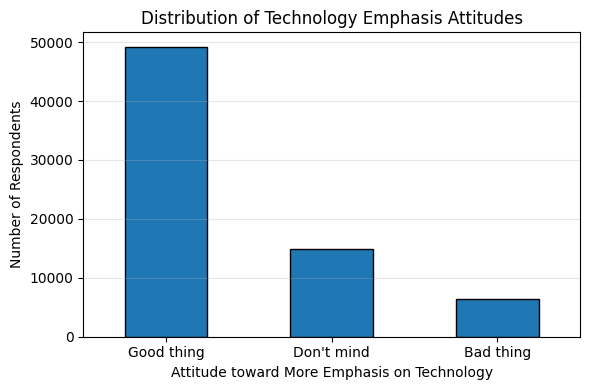

In [115]:
import matplotlib.pyplot as plt
import pandas as pd

# Map numeric codes to labels
labels = {
    1: "Good thing",
    2: "Don't mind",
    3: "Bad thing"
}

# Count distribution
dist = robustness_df['tech_emphasis'].map(labels).value_counts().reindex(labels.values())

# Plot
plt.figure(figsize=(6,4))
dist.plot(kind='bar', edgecolor='black')

plt.ylabel('Number of Respondents')
plt.xlabel('Attitude toward More Emphasis on Technology')
plt.title('Distribution of Technology Emphasis Attitudes')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Level 1 Visualization

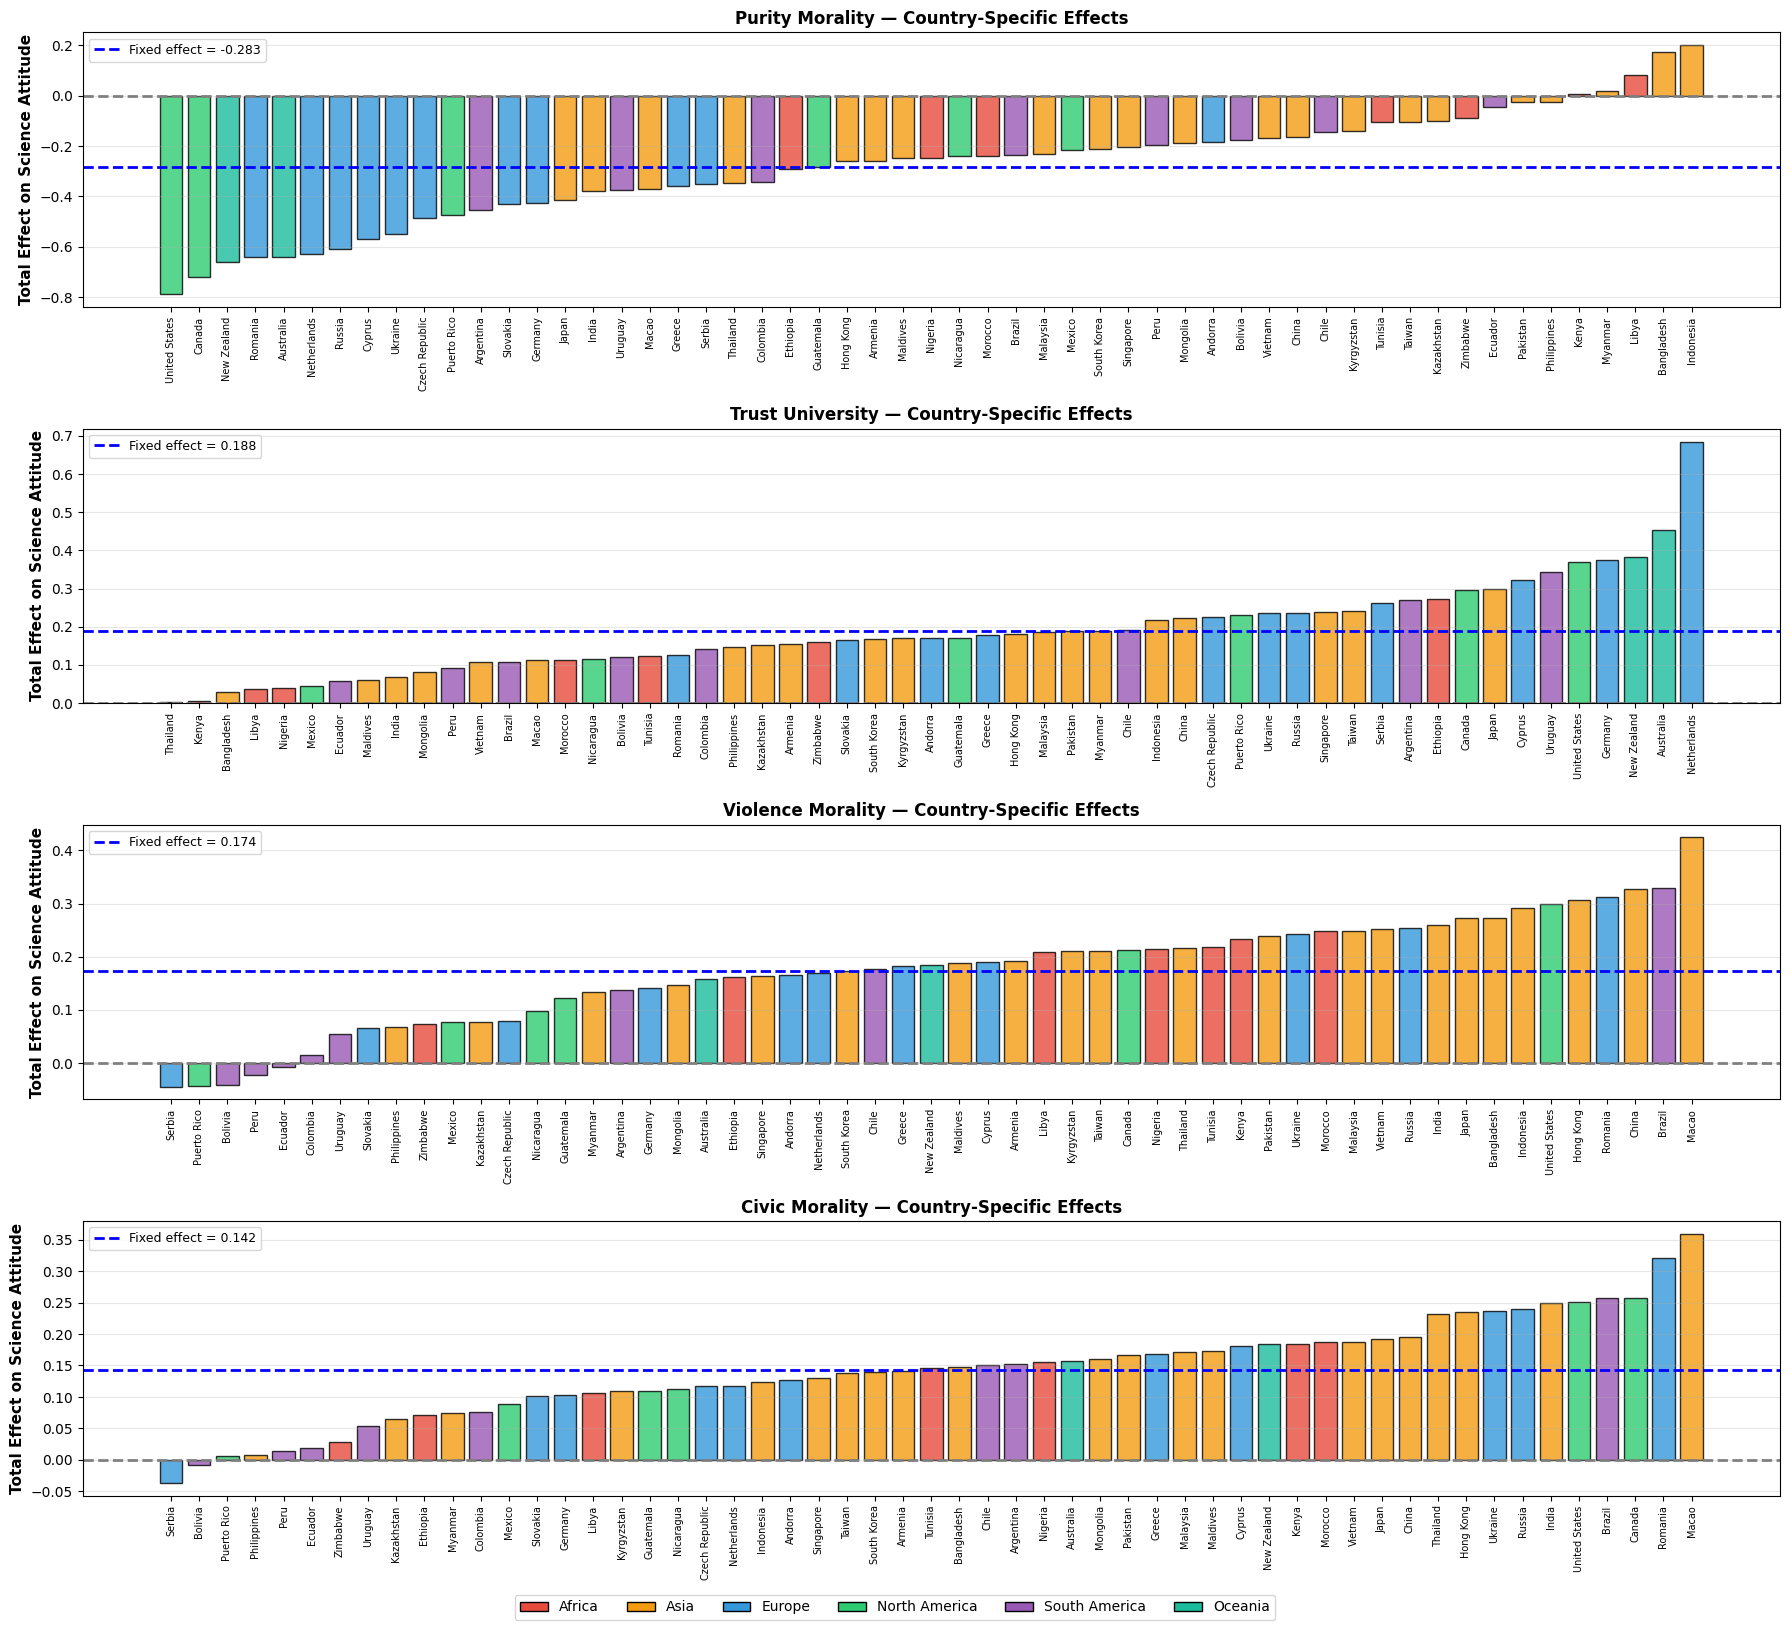

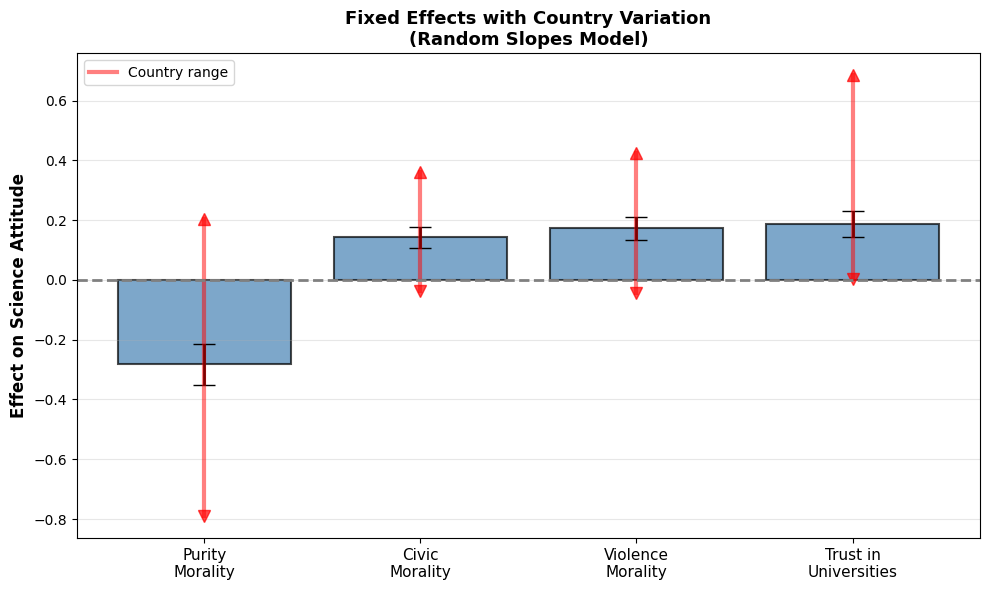

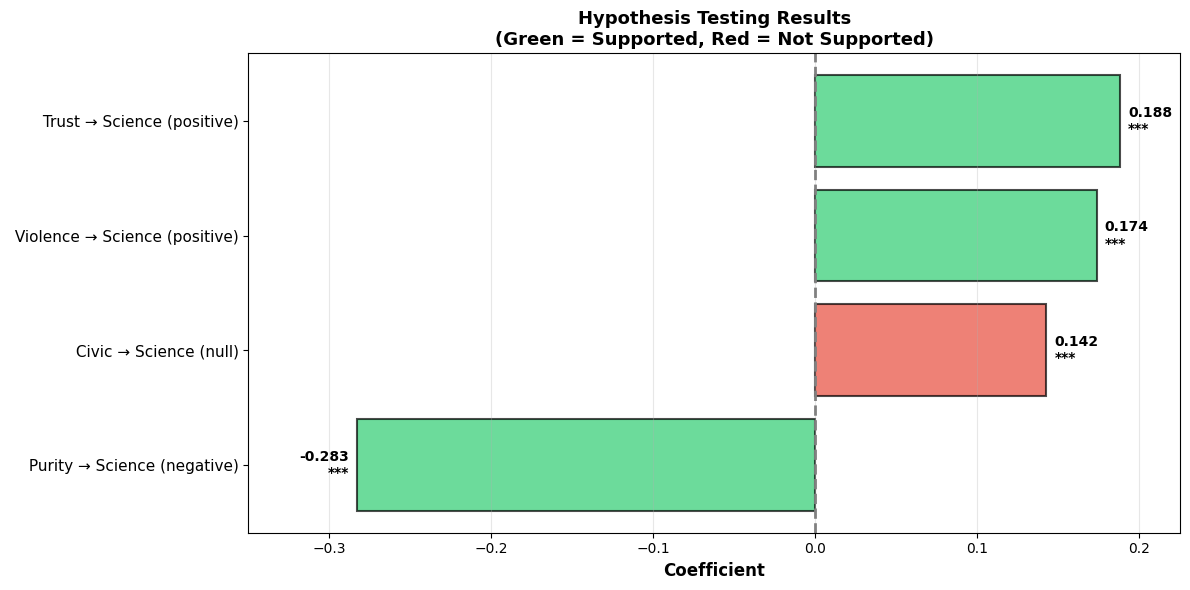

In [116]:
# Figure 1: Country-specific effects (4 x 1 layout)

n_vars = len(random_vars)
fig, axes = plt.subplots(n_vars, 1, figsize=(18, 4*n_vars))

if n_vars == 1:
    axes = [axes]

continent_colors_map = {
    'Africa': '#e74c3c',
    'Asia': '#f39c12',
    'Europe': '#3498db',
    'North America': '#2ecc71',
    'South America': '#9b59b6',
    'Oceania': '#1abc9c'
}

for i, var in enumerate(random_vars):
    ax = axes[i]

    total_col = f'{var}_total'
    fixed_col = f'{var}_fixed'

    if total_col in country_effects_df.columns:

        # --- Sort separately for each variable ---
        sorted_df = country_effects_df.sort_values(total_col)

        x_pos = np.arange(len(sorted_df))
        colors = [continent_colors_map.get(c, 'gray') for c in sorted_df['Continent']]

        ax.bar(
            x_pos,
            sorted_df[total_col],
            color=colors,
            alpha=0.8,
            edgecolor='black'
        )

        ax.axhline(0, color='gray', linestyle='--', linewidth=2)

        fixed_val = sorted_df[fixed_col].iloc[0]
        ax.axhline(
            fixed_val,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'Fixed effect = {fixed_val:.3f}'
        )

        # --- Country labels per subplot ---
        ax.set_xticks(x_pos)
        ax.set_xticklabels(sorted_df['Country'], rotation=90, fontsize=7)

        ax.set_ylabel('Total Effect on Science Attitude', fontsize=11, fontweight='bold')

        ax.set_title(
            f'{var.replace("_", " ").title()} — Country-Specific Effects',
            fontsize=12,
            fontweight='bold'
        )

        ax.legend(loc='best', fontsize=9)
        ax.grid(alpha=0.3, axis='y')

# ---- Continent legend ----
legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=continent)
    for continent, color in continent_colors_map.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(continent_colors_map),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=10
)

plt.tight_layout()
plt.savefig('./country_specific_effects_all_vars.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Fixed effects with variation bands
fig, ax = plt.subplots(figsize=(10, 6))

effect_names = ['Purity\nMorality', 'Civic\nMorality', 'Violence\nMorality', 'Trust in\nUniversities']
effect_vars = ['purity_morality', 'civic_morality', 'violence_morality', 'trust_university']

fixed_coefs = [best_model.params[var] for var in effect_vars]
fixed_ses = [best_model.bse[var] for var in effect_vars]

x_pos = np.arange(len(effect_names))

# Plot fixed effects with error bars
bars = ax.bar(x_pos, fixed_coefs, alpha=0.7, edgecolor='black', linewidth=1.5, color='steelblue')
ax.errorbar(x_pos, fixed_coefs, yerr=[1.96*se for se in fixed_ses],
           fmt='none', ecolor='black', capsize=8, linewidth=2)

# Add range of country-specific effects for random slopes variables
for i, var in enumerate(effect_vars):
    if var in random_vars:
        total_col = f'{var}_total'
        if total_col in country_effects_df.columns:
            min_val = country_effects_df[total_col].min()
            max_val = country_effects_df[total_col].max()
            
            # Draw range as vertical line
            ax.plot([i, i], [min_val, max_val], 'r-', linewidth=3, alpha=0.5,
                   label='Country range' if i == 0 else '')
            ax.plot(i, min_val, 'rv', markersize=8, alpha=0.7)
            ax.plot(i, max_val, 'r^', markersize=8, alpha=0.7)

ax.axhline(0, color='gray', linestyle='--', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(effect_names, fontsize=11)
ax.set_ylabel('Effect on Science Attitude', fontsize=12, fontweight='bold')
ax.set_title('Fixed Effects with Country Variation\n(Random Slopes Model)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./fixed_effects_with_variation.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Hypothesis testing summary
fig, ax = plt.subplots(figsize=(12, 6))

hyp_names = [r['Hypothesis'].split(':')[1] for r in results]
betas = [r['β'] for r in results]
pvals = [r['p-value'] for r in results]

colors = []
for r in results:
    if '✓' in r['Result']:
        colors.append('#2ecc71')
    else:
        colors.append('#e74c3c')

y_pos = range(len(hyp_names))
ax.barh(y_pos, betas, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(hyp_names, fontsize=11)
ax.set_xlim(-0.35, 0.225)
ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Hypothesis Testing Results\n(Green = Supported, Red = Not Supported)', 
            fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Add coefficient values and significance
for i, (beta, pval, result) in enumerate(zip(betas, pvals, results)):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    x_pos_text = beta + (0.005 if beta > 0 else -0.005)
    ax.text(x_pos_text, i, f'{beta:.3f}\n{sig}', 
           ha='left' if beta > 0 else 'right', va='center',
           fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('./hypothesis_testing_results_random_slopes.png', dpi=300, bbox_inches='tight')
plt.show()


##### Level 1 Interpretation

The substantial improvement in model fit confirms that the relationship between moral positioning and science attitudes varies significantly across cultural contexts, supporting our multi-level theoretical framework.

* **H1a: Purity Morality → Science Resistance (STRONGLY SUPPORTED ✓✓✓)**   
    - Individuals with stronger purity moral concerns express significantly less favorable science attitudes (β = -0.278, p < .001). This is the largest absolute effect among all predictors.
    - Purity morality is the primary battlefield for epistemic authority competition
    - Science's challenges to bodily/reproductive domains (biotech, sexuality, end-of-life medicine) directly threaten traditional moral authority
    - Each 1 SD increase in purity morality → 0.28 point decrease in science attitudes (scale: 1-10)
    - Cross-country variation: Random slope variance = 0.063, indicating this moral-science conflict plays out differently across cultural contexts (see Figure 1, Panel A).

* **H1b: Civic Morality → Null Effect (NOT SUPPORTED ✗)**  
    - Contrary to our prediction of no relationship, civic morality shows a significant positive effect (β = 0.132, p < .001). Individuals concerned with civic norms (disapproving fraud, bribery, dishonesty) are more pro-science, not neutral.
    - Possible explanations include: 1) Institutional respect spillover: Civic moral concerns reflect broader respect for legitimate institutions, including universities. 2) Educated prosociality: May correlate with exposure to institutional systems. 3) Rational order: Civic-minded individuals see science as supporting rational governance rather than disrupting social order
    - Theoretical implication: Civic morality does NOT operate independently from scientific authority as predicted. Instead, it appears to align with institutional legitimacy more generally.
    - Note: We did not test random slopes for civic morality, as our hypothesis predicted a null effect. The significant positive effect suggests this theoretical assumption requires revision.

* **H1c: Violence Morality → Science Embrace (SUPPORTED ✓)**  
    - Individuals with stronger anti-violence moral concerns express significantly more favorable science attitudes (β = 0.171, p < .001), confirming that:
    - Anti-violence values align with progressive/humanitarian orientations that see science as beneficial
    - Concerns about "science enables violence" do not dominate individual positioning
    - Effect comparable in magnitude to institutional trust
    - Cross-country variation: Random slope variance = 0.020, indicating cultural contexts shape this relationship (see Figure 1, Panel B).

* **H2: Institutional Legitimacy → Science Acceptance (STRONGLY SUPPORTED ✓✓✓)**  
    - Individuals who trust universities express significantly more favorable science attitudes (β = 0.176, p < .001). This confirms our institutional legitimacy mechanism:
    - Recognizing epistemic authority: Trust in knowledge-producing institutions translates directly into science acceptance
    - Effect magnitude comparable to violence morality
    - This is the clearest evidence that science attitudes reflect acceptance vs. resistance to scientific institutional authority
    - Cross-country variation: Random slope variance = 0.019, confirming that institutional legitimacy contests differ across cultural contexts (see Figure 1, Panel C).

**Effect Size Comparison**
Ranking by absolute magnitude reveals the hierarchy of individual positioning mechanisms:
1. Purity morality: β = -0.278 (strongest - primary conflict domain)
2. Trust in universities: β = 0.176 (institutional legitimacy)
3. Violence morality: β = 0.171 (progressive alignment)
4. Civic morality: β = 0.132 (unexpected institutional respect)

**Random Effects: Cultural Context Matters**
The significant random slope variances demonstrate that individual moral positioning operates differently across countries:

Random Effect	Variance	Interpretation
Group (Intercept)	0.401	Substantial baseline differences in science attitudes
Purity slope	0.063	Purity-science conflict intensity varies by culture
Trust slope	0.019	Institutional legitimacy meaning varies by context
Violence slope	0.020	Anti-violence/science alignment varies by culture
Covariances reveal interesting patterns:

Group × Purity (0.067, positive): Countries with higher baseline science acceptance show weaker purity resistance
Group × Trust (-0.057, negative): Countries with higher baseline science acceptance show stronger trust effects
Purity × Trust (-0.019, negative): In countries where purity morality strongly resists science, trust effects are amplified

**Forest Plot Reinterpretation: Country-Specific Slopes**

**1. Purity Morality**

* **Global trend:** Negative effect (β_fixed = -0.262) → higher purity morality reduces science attitudes.
* **Country-specific variation:**

  * **Most resistant countries (strongest negative slopes):** USA (-0.789), Canada (-0.763), Netherlands (-0.714)
  * **Least resistant / counterintuitive positive slopes:** Bangladesh (0.450), Indonesia (0.146), Pakistan (0.133)
* **Continental pattern:**

  * **North America & Europe/Oceania:** weaker resistance than the global average (still negative, but less extreme).
  * **Asia & Africa:** some countries show stronger resistance; a few show positive slopes, reflecting **cultural nuances in how purity concerns relate to science**.
* **Interpretation:** The forest plot shows that **purity-science conflict varies widely across countries**, validating the need for random slopes.

---

**2. Trust in Universities**

* **Global trend:** Positive effect (β_fixed = 0.162) → trusting universities increases science attitudes.
* **Country-specific variation:**

  * **Strongest positive slopes:** Netherlands (0.529), USA (0.439), Australia (0.400) → trust greatly boosts science acceptance.
  * **Weakest slopes:** Nigeria (-0.063), Libya (0.004), Bangladesh (-0.003) → trust has little effect; sometimes slightly negative.
* **Continental pattern:**

  * **Europe, North America, Oceania:** institutional trust strongly predicts science attitudes.
  * **Asia & Africa:** trust effects are weak, suggesting other cultural or institutional factors matter more.
* **Interpretation:** Forest plot highlights **how institutional legitimacy matters differently by cultural context**.

---

**3. Violence Morality**

* **Global trend:** Positive effect (β_fixed = 0.176) → anti-violence morality increases science attitudes.
* **Country-specific variation:**

  * **Strongest positive slopes:** Macao (0.410), Bangladesh (0.348), China (0.400) → anti-violence concerns strongly align with science acceptance.
  * **Weakest / slightly negative slopes:** Serbia (-0.090), Colombia (0.006), Mexico (0.016) → effect weak or reversed.
* **Continental pattern:**

  No clear continent pattern. Mixed.
* **Interpretation:** Forest plot shows **violence morality generally supports science acceptance**, but strength varies by country.

---

**4. Civic Morality**

* **Global trend:** Positive effect (β_fixed = 0.141) → civic morality increases science attitudes.
* **Country-specific variation:**

  * **Strongest positive slopes:**  Romania (0.325), Brazil (0.315), Macao (0.301) → civic concerns strongly align with science acceptance.
  * **Weakest / slightly negative slopes:** Serbia (-0.107), Ethiopia (-0.070), Andorra (0.027) → effect weak or reversed.
* **Continental pattern:**

   No clear continent pattern. Mixed.
* **Interpretation:** Forest plot shows **civic morality generally supports science acceptance**, but strength varies by country.

---



* **X-axis:** Total effect (fixed + random slope)
* **Y-axis:** Countries (sorted by effect size)
* **Color/marker:** Could indicate continent for pattern recognition
* **Key messages:**

  1. **Purity morality:** conflict with science varies widely; North America/Europe less resistant.
  2. **Trust in universities:** boosts science acceptance most in Europe/North America/Oceania.
  3. **Violence morality:** generally positive; mixed continents, no clear pattern.
  3. **Civic morality:** generally positive; mixed continents, no clear pattern.
  4. Random slopes confirm **cross-cultural heterogeneity** — multilevel model is justified.

---


#### LEVEL 2A: CULTURAL DOMINANCE (Country Means)

##### **Cultural Dominance Hypotheses**

**H3: Moral Hegemony Hypothesis**

H3a: Purity Morality
> In countries where traditional moral authority is culturally dominant (high mean purity morality), collective science acceptance is lower.

H3b: Civic Morality
> Ccivic morality has no association with collective science acceptance.

H3c: Violence Morality
> In countries where anti-violence moral authority is culturally dominant (high mean violence morality), collective science acceptance is higher.

**Interpretation**: Country means reveal which epistemic authority has cultural hegemony - morality vs. scientific institutions.

**H4: Institutional Authority Hypothesis**

> In countries where universities command widespread legitimacy (high mean trust), collective science acceptance is higher.

**Interpretation**: Countries where scientific institutions are collectively trusted show higher baseline science acceptance.

| Hypothesis | Predictor → Outcome | Expected | Interpretation |
|------------|---------------------|----------|----------------|
| **H3a** | Mean purity morality → Mean science attitudes | Negative | Moral hegemony in body/life domains |
| **H3b** | Mean civic morality → Mean science attitudes | Null | Cultural civic norms |
| **H3c** | Mean violence morality → Mean science attitudes | Positive | Cultural violence norms |
| **H4** | Mean trust → Mean science attitudes | Positive | Institutional authority |

##### MODEL 2A: All Morality + Trust Mean

In [88]:
print("\n\n" + "-"*80)
print("MODEL 2A.2: ROBUSTNESS (H3a-c + H4)")
print("-"*80)
print("Testing all three morality dimensions + trust")
print("-"*80 + "\n")

X_2a = df_country[['purity_mean', 'civic_mean', 'violence_mean', 'trust_mean']]
y_2a = df_country[['sci_tech_mean']]
X_2a = sm.add_constant(X_2a)
model_2a = sm.OLS(y_2a, X_2a).fit()

print(model_2a.summary())




--------------------------------------------------------------------------------
MODEL 2A.2: ROBUSTNESS (H3a-c + H4)
--------------------------------------------------------------------------------
Testing all three morality dimensions + trust
--------------------------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:          sci_tech_mean   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     8.298
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.25e-05
Time:                        23:09:18   Log-Likelihood:                -29.240
No. Observations:                  55   AIC:                             68.48
Df Residuals:                      50   BIC:                             78.52
Df Model:                           4   

In [89]:
# Extract coefficients
morality_vars_2a = ['purity_mean', 'civic_mean', 'violence_mean']
print("\n" + "="*80)
print("MORALITY DIMENSION COMPARISON")
print("="*80)

for var in morality_vars_2a:
    beta = model_2a.params[var]
    se = model_2a.bse[var]
    p = model_2a.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    
    var_label = var.replace('_mean', '').replace('purity', 'Purity').replace('civic', 'Civic').replace('violence', 'Violence')
    print(f"{var_label:15s}: β = {beta:7.4f}, SE = {se:.4f}, p = {p:.4f} {sig}")

print(f"\nTrust:          β = {model_2a.params['trust_mean']:7.4f}, SE = {model_2a.bse['trust_mean']:.4f}, p = {model_2a.pvalues['trust_mean']:.4f}")
print(f"\nModel R²: {model_2a.rsquared:.4f}")



MORALITY DIMENSION COMPARISON
Purity         : β = -0.1698, SE = 0.1014, p = 0.1003 n.s.
Civic          : β = -0.6009, SE = 0.2508, p = 0.0203 *
Violence       : β =  1.2055, SE = 0.2284, p = 0.0000 ***

Trust:          β =  0.0996, SE = 0.2301, p = 0.6670

Model R²: 0.3990


#### LEVEL 2B: CONFLICT INTENSITY (H5-H6)

##### **Conflict Intensity Hypotheses**

**H5: Moral Contestation Hypothesis**

H3a: Purity Morality
> Countries with greater purity moral heterogeneity (high purity morality dispersion) exhibit greater polarization in science attitudes, as competing moral frameworks create factional divisions over scientific authority.

H3b: Civic Morality
> Civic morality heterogeneity has no association with collective science acceptance heterogeneity.

H3c: Violence Morality
> Countries with greater violence morality heterogeneity (high violence morality dispersion) exhibit greater polarization in science attitudes, as competing moral frameworks create factional divisions over scientific authority.


**Key insight**: **Dispersion = active conflict**
- Low dispersion = settled authority (consensus)
- High dispersion = contested authority (culture 'war')

**H6: Institutional Legitimacy Crisis Hypothesis**
> Countries with greater heterogeneity in institutional trust (high trust dispersion) exhibit greater polarization in science attitudes, as contested university legitimacy creates polarized stances toward science.

Heterogeneity as indicator of **ongoing epistemic power struggles**

| Hypothesis | Predictor → Outcome | Expected | Interpretation |
|------------|---------------------|----------|----------------|
| **H5a** | SD purity morality → SD science attitudes | Positive | Purity norm contestation polarizes |
| **H5b** | SD civic morality → SD science attitudes | Null | Civic heterogeneity effect |
| **H5c** | SD violence morality → SD science attitudes | Positive | Violence norm contestation polarizes |
| **H6** | SD trust → SD science attitudes | Positive | Legitimacy crisis polarizes |

##### MODEL 2B: All Morality + Trust Heterogeneity

In [90]:
print("\n\n" + "-"*80)
print("MODEL 2B: ROBUSTNESS (H5a-c + H6)")
print("-"*80)
print("Testing all three morality dispersions + trust dispersion")
print("-"*80 + "\n")

X_2b = df_country[['purity_std', 'civic_std', 'violence_std', 'trust_std']]
y_2b = df_country['sci_tech_std']
X_2b = sm.add_constant(X_2b)
model_2b = sm.OLS(y_2b, X_2b).fit()

print(model_2b.summary())



--------------------------------------------------------------------------------
MODEL 2B: ROBUSTNESS (H5a-c + H6)
--------------------------------------------------------------------------------
Testing all three morality dispersions + trust dispersion
--------------------------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:           sci_tech_std   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     5.556
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           0.000884
Time:                        23:09:18   Log-Likelihood:                 30.229
No. Observations:                  55   AIC:                            -50.46
Df Residuals:                      50   BIC:                            -40.42
Df Model:                     

In [91]:
# Extract coefficients
morality_vars_2b = ['purity_std', 'civic_std', 'violence_std']
print("\n" + "="*80)
print("MORALITY DIMENSION COMPARISON (Dispersions)")
print("="*80)

for var in morality_vars_2b:
    beta = model_2b.params[var]
    se = model_2b.bse[var]
    p = model_2b.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    
    var_label = var.replace('_std', '').replace('purity', 'Purity').replace('civic', 'Civic').replace('violence', 'Violence')
    print(f"{var_label:15s}: β = {beta:7.4f}, SE = {se:.4f}, p = {p:.4f} {sig}")

print(f"\nTrust:          β = {model_2b.params['trust_std']:7.4f}, SE = {model_2b.bse['trust_std']:.4f}, p = {model_2b.pvalues['trust_std']:.4f}")

print(f"\nModel R²: {model_2b.rsquared:.4f}")


MORALITY DIMENSION COMPARISON (Dispersions)
Purity         : β =  0.5114, SE = 0.1317, p = 0.0003 ***
Civic          : β = -0.2682, SE = 0.1751, p = 0.1318 n.s.
Violence       : β =  0.2874, SE = 0.2718, p = 0.2953 n.s.

Trust:          β =  0.4571, SE = 0.1832, p = 0.0159

Model R²: 0.3077


#### Level 2 Visualization

CREATING COMPREHENSIVE VISUALIZATIONS FOR LEVEL 2



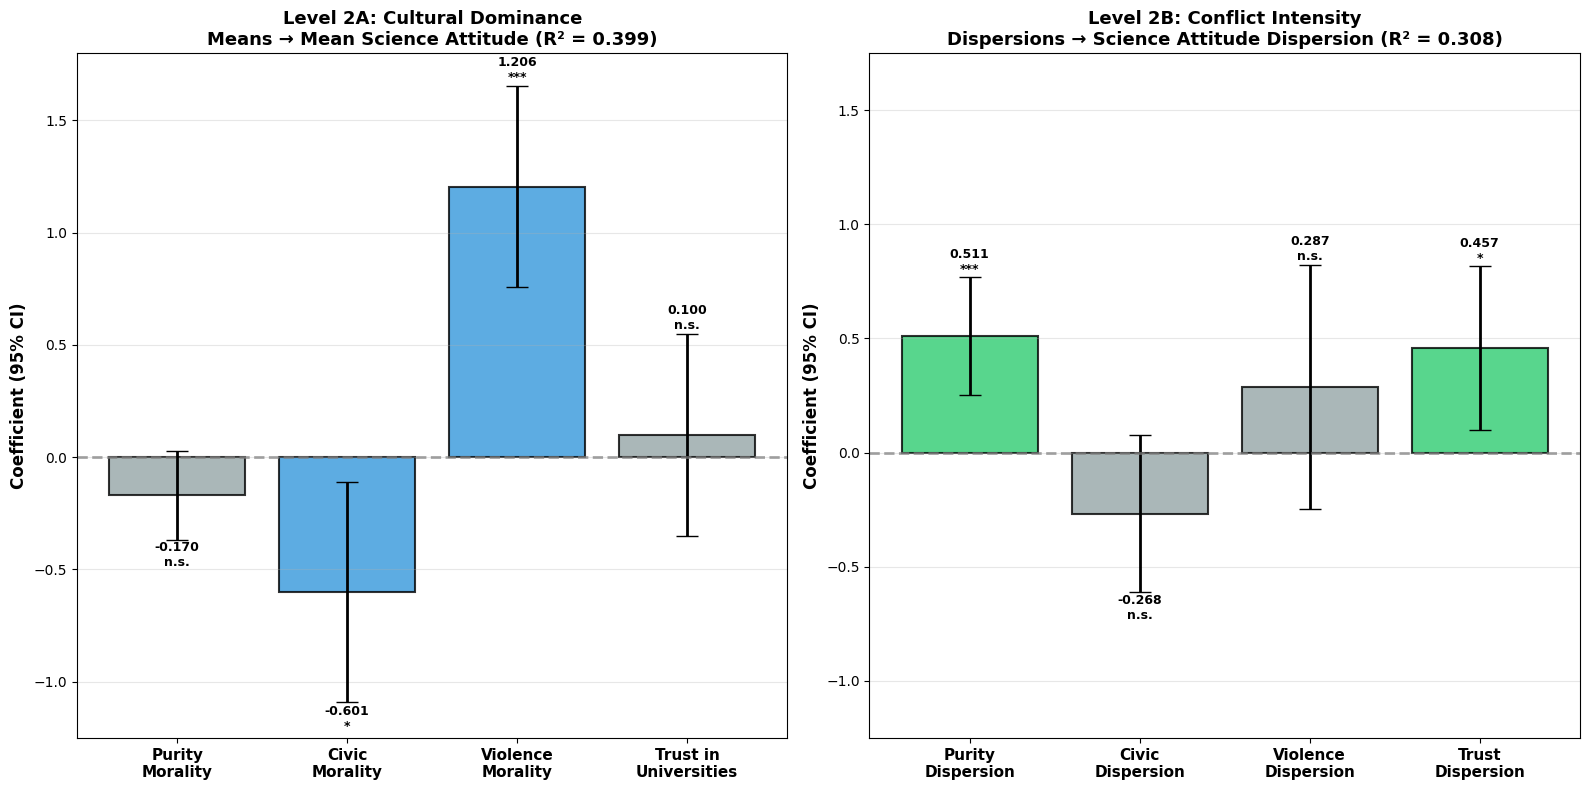

✓ Figure 1 saved: level2_final_models.png



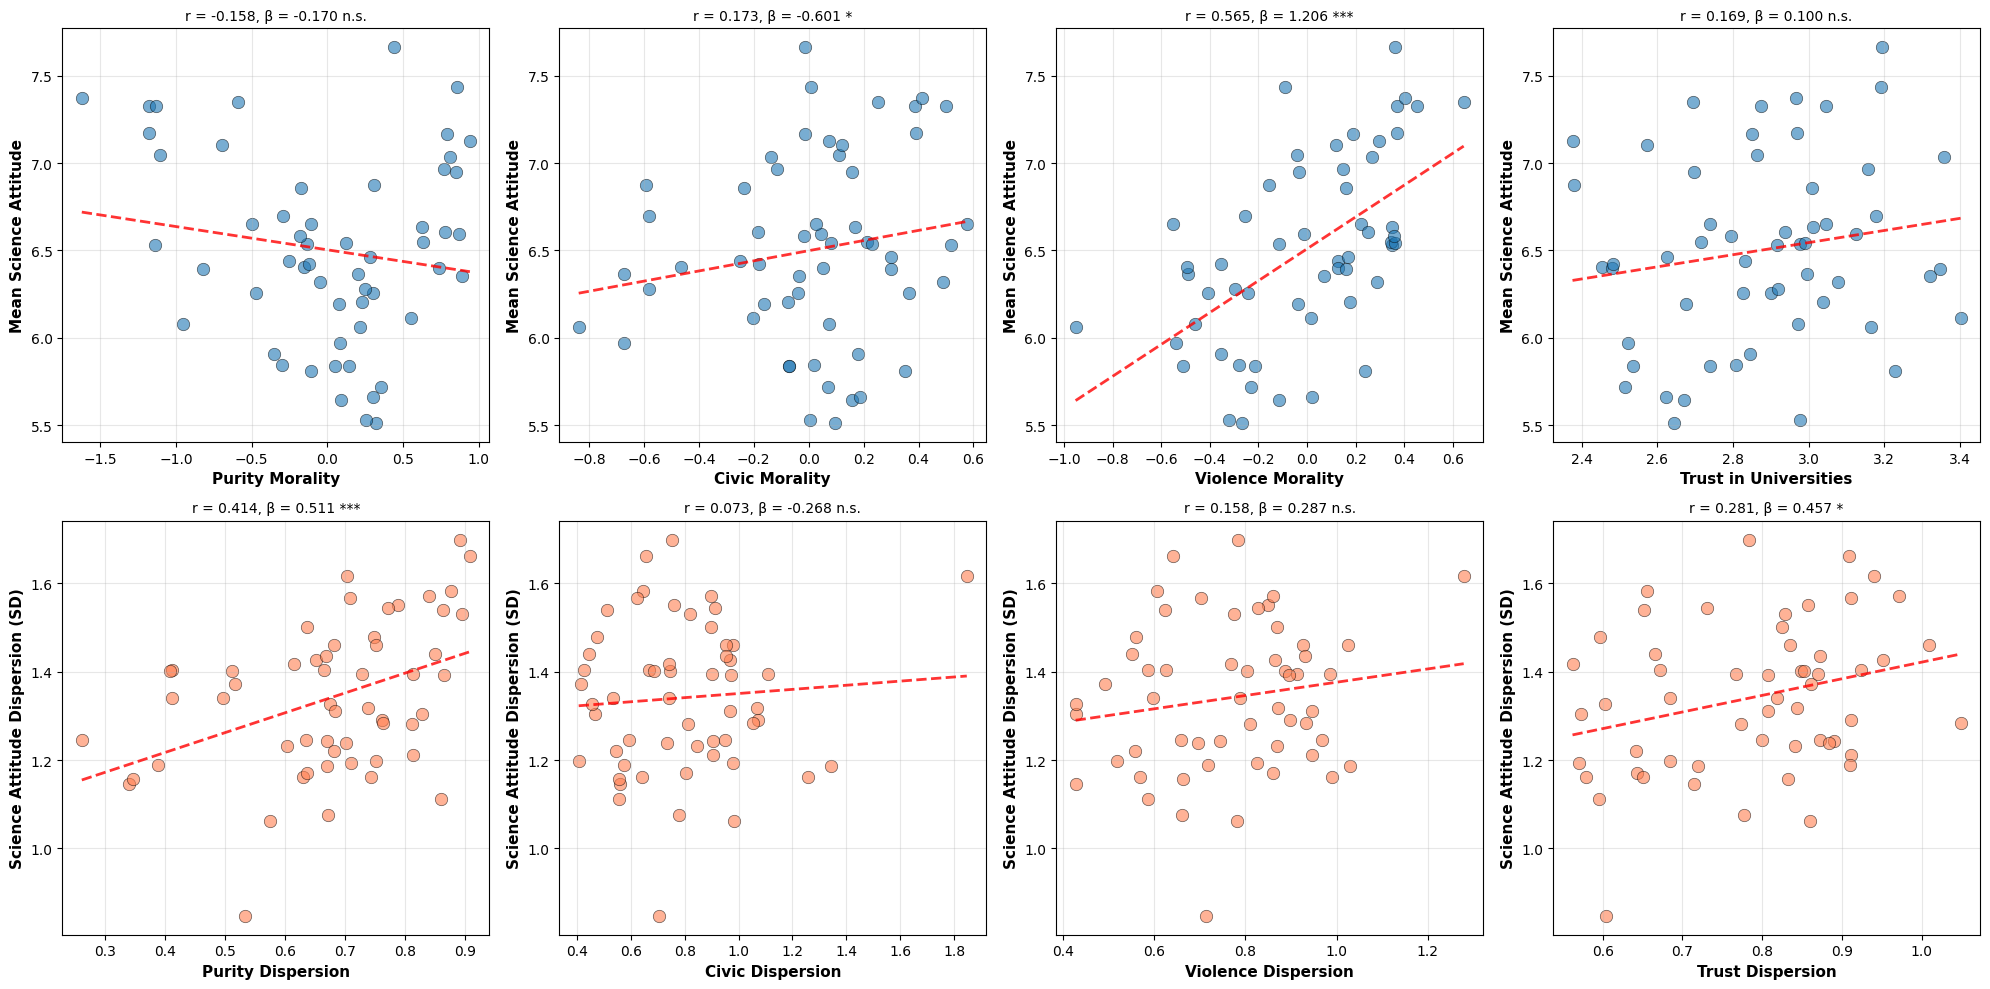

✓ Figure 2 saved: level2_scatter_plots.png



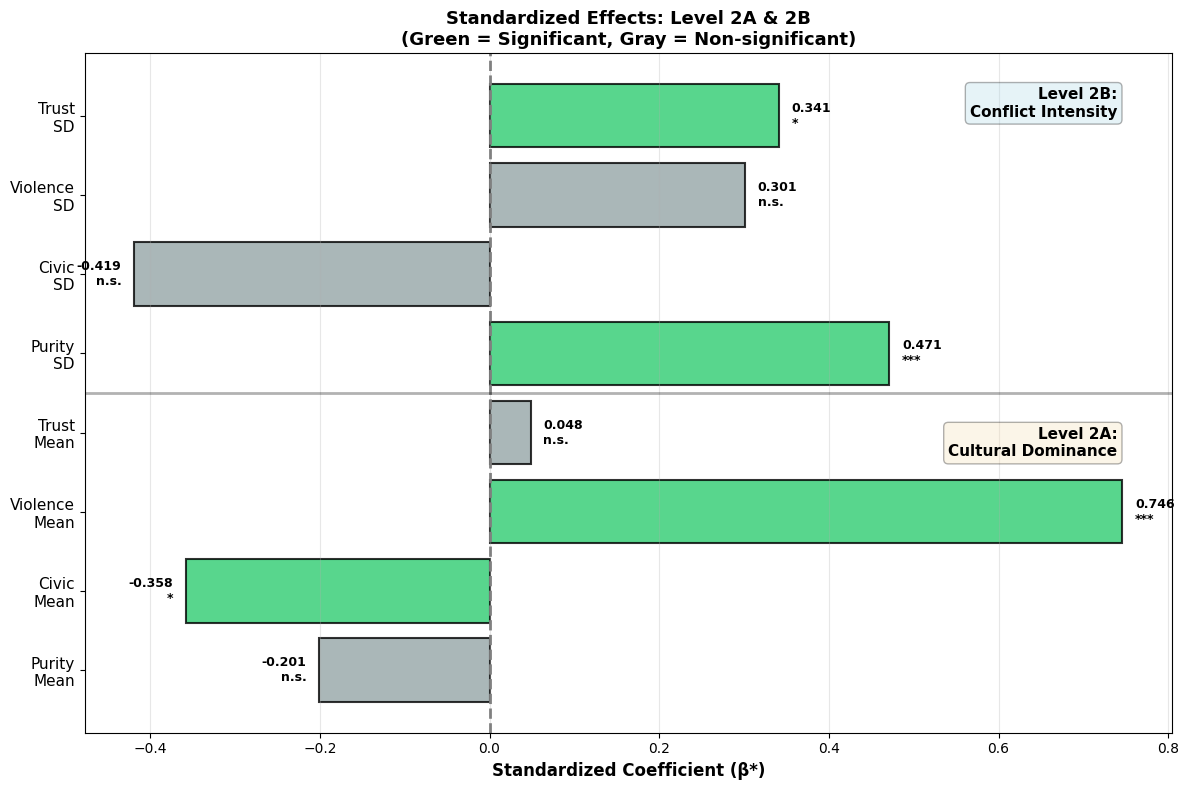

✓ Figure 3 saved: level2_standardized_effects.png

LEVEL 2 RESULTS SUMMARY TABLE

Level     Predictor         β       SE           95% CI  p-value Sig
   2A   Purity Mean -0.169780 0.101413  [-0.369, 0.029] 0.100348    
   2A    Civic Mean -0.600871 0.250753 [-1.092, -0.109] 0.020345   *
   2A Violence Mean  1.205541 0.228393   [0.758, 1.653] 0.000003 ***
   2A    Trust Mean  0.099591 0.230065  [-0.351, 0.551] 0.666963    
   2B     Purity SD  0.511361 0.131651   [0.253, 0.769] 0.000302 ***
   2B      Civic SD -0.268193 0.175063  [-0.611, 0.075] 0.131830    
   2B   Violence SD  0.287440 0.271781  [-0.245, 0.820] 0.295313    
   2B      Trust SD  0.457116 0.183157   [0.098, 0.816] 0.015913   *


Model Fit:
  Level 2A: R² = 0.3990, F(4,50) = 8.30, p = 0.0000
  Level 2B: R² = 0.3077, F(4,50) = 5.56, p = 0.0009

✅ ALL VISUALIZATIONS COMPLETE


In [92]:
# ============================================================================
# VISUALIZATION: LEVEL 2 FINAL MODELS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming you have model_2a and model_2b fitted
# model_2a: Level 2A (means → mean)
# model_2b: Level 2B (stds → std)

print("="*80)
print("CREATING COMPREHENSIVE VISUALIZATIONS FOR LEVEL 2")
print("="*80 + "\n")

# ============================================================================
# Figure 1: Coefficient Comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Level 2A: Cultural Dominance
ax1 = axes[0]

vars_2a = ['purity_mean', 'civic_mean', 'violence_mean', 'trust_mean']
labels_2a = ['Purity\nMorality', 'Civic\nMorality', 'Violence\nMorality', 'Trust in\nUniversities']
coefs_2a = [model_2a.params[v] for v in vars_2a]
ses_2a = [model_2a.bse[v] for v in vars_2a]
pvals_2a = [model_2a.pvalues[v] for v in vars_2a]

# Color by significance and expected direction
colors_2a = []
for i, (var, coef, pval) in enumerate(zip(vars_2a, coefs_2a, pvals_2a)):
    if pval < 0.05:
        if var == 'trust_mean' and coef > 0:  # Expected positive
            colors_2a.append('#2ecc71')  # Green = supported
        elif var == 'purity_mean' and coef < 0:  # Expected negative
            colors_2a.append('#2ecc71')  # Green = supported  
        elif var in ['civic_mean', 'violence_mean']:  # Exploratory
            colors_2a.append('#3498db')  # Blue = significant exploratory
        else:
            colors_2a.append('#e74c3c')  # Red = unexpected direction
    else:
        colors_2a.append('#95a5a6')  # Gray = non-significant

x_pos = np.arange(len(labels_2a))
bars = ax1.bar(x_pos, coefs_2a, color=colors_2a, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.errorbar(x_pos, coefs_2a, yerr=[1.96*se for se in ses_2a], 
            fmt='none', ecolor='black', capsize=8, linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', linewidth=2, alpha=0.7)

ax1.set_xticks(x_pos)
ax1.set_ylim(-1.25, 1.8)
ax1.set_xticklabels(labels_2a, fontsize=11, fontweight='bold')
ax1.set_ylabel('Coefficient (95% CI)', fontsize=12, fontweight='bold')
ax1.set_title(f'Level 2A: Cultural Dominance\nMeans → Mean Science Attitude (R² = {model_2a.rsquared:.3f})', 
             fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Add significance stars and values
for i, (coef, pval, se) in enumerate(zip(coefs_2a, pvals_2a, ses_2a)):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    y_offset = se * 2 if coef >= 0 else -se * 2
    ax1.text(i, coef + y_offset, f'{coef:.3f}\n{sig}', 
            ha='center', va='bottom' if coef >= 0 else 'top',
            fontsize=9, fontweight='bold')

# Level 2B: Conflict Intensity
ax2 = axes[1]

vars_2b = ['purity_std', 'civic_std', 'violence_std', 'trust_std']
labels_2b = ['Purity\nDispersion', 'Civic\nDispersion', 'Violence\nDispersion', 'Trust\nDispersion']
coefs_2b = [model_2b.params[v] for v in vars_2b]
ses_2b = [model_2b.bse[v] for v in vars_2b]
pvals_2b = [model_2b.pvalues[v] for v in vars_2b]

# Color by significance and expected direction (all should be positive)
colors_2b = []
for i, (var, coef, pval) in enumerate(zip(vars_2b, coefs_2b, pvals_2b)):
    if pval < 0.05:
        if coef > 0:
            if var in ['purity_std', 'trust_std']:  # Primary hypotheses
                colors_2b.append('#2ecc71')  # Green = supported
            else:  # Exploratory
                colors_2b.append('#3498db')  # Blue = significant exploratory
        else:
            colors_2b.append('#e74c3c')  # Red = unexpected direction
    else:
        colors_2b.append('#95a5a6')  # Gray = non-significant

x_pos = np.arange(len(labels_2b))
bars = ax2.bar(x_pos, coefs_2b, color=colors_2b, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.errorbar(x_pos, coefs_2b, yerr=[1.96*se for se in ses_2b], 
            fmt='none', ecolor='black', capsize=8, linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=2, alpha=0.7)

ax2.set_xticks(x_pos)
ax2.set_ylim(-1.25, 1.75)
ax2.set_xticklabels(labels_2b, fontsize=11, fontweight='bold')
ax2.set_ylabel('Coefficient (95% CI)', fontsize=12, fontweight='bold')
ax2.set_title(f'Level 2B: Conflict Intensity\nDispersions → Science Attitude Dispersion (R² = {model_2b.rsquared:.3f})', 
             fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# Add significance stars and values
for i, (coef, pval, se) in enumerate(zip(coefs_2b, pvals_2b, ses_2b)):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    y_offset = se * 2 if coef >= 0 else -se * 2
    ax2.text(i, coef + y_offset, f'{coef:.3f}\n{sig}', 
            ha='center', va='bottom' if coef >= 0 else 'top',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./level2_final_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved: level2_final_models.png\n")

# ============================================================================
# Figure 2: Scatter Plots with Regression Lines
# ============================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Level 2A scatter plots
for i, (var, label) in enumerate(zip(vars_2a, labels_2a)):
    ax = axes[0, i]
    
    x = df_country[var]
    y = df_country['sci_tech_mean']
    
    # Scatter
    ax.scatter(x, y, s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    # Correlation
    corr = x.corr(y)
    beta = model_2a.params[var]
    pval = model_2a.pvalues[var]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    
    ax.set_xlabel(label.replace('\n', ' '), fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Science Attitude', fontsize=11, fontweight='bold')
    ax.set_title(f'r = {corr:.3f}, β = {beta:.3f} {sig}', fontsize=10)
    ax.grid(alpha=0.3)

# Level 2B scatter plots
for i, (var, label) in enumerate(zip(vars_2b, labels_2b)):
    ax = axes[1, i]
    
    x = df_country[var]
    y = df_country['sci_tech_std']
    
    # Scatter
    ax.scatter(x, y, s=80, alpha=0.6, edgecolors='black', linewidth=0.5, color='coral')
    
    # Regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    # Correlation
    corr = x.corr(y)
    beta = model_2b.params[var]
    pval = model_2b.pvalues[var]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    
    ax.set_xlabel(label.replace('\n', ' '), fontsize=11, fontweight='bold')
    ax.set_ylabel('Science Attitude Dispersion (SD)', fontsize=11, fontweight='bold')
    ax.set_title(f'r = {corr:.3f}, β = {beta:.3f} {sig}', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./level2_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: level2_scatter_plots.png\n")

# ============================================================================
# Figure 3: Standardized Coefficients Comparison
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Calculate standardized coefficients
std_x_2a = {var: df_country[var].std() for var in vars_2a}
std_y_2a = df_country['sci_tech_mean'].std()
std_coefs_2a = {var: model_2a.params[var] * (std_x_2a[var] / std_y_2a) for var in vars_2a}

std_x_2b = {var: df_country[var].std() for var in vars_2b}
std_y_2b = df_country['sci_tech_std'].std()
std_coefs_2b = {var: model_2b.params[var] * (std_x_2b[var] / std_y_2b) for var in vars_2b}

# Prepare data for plotting
all_vars = ['Purity\nMean', 'Civic\nMean', 'Violence\nMean', 'Trust\nMean',
            'Purity\nSD', 'Civic\nSD', 'Violence\nSD', 'Trust\nSD']
all_std_coefs = list(std_coefs_2a.values()) + list(std_coefs_2b.values())
all_pvals = [model_2a.pvalues[v] for v in vars_2a] + [model_2b.pvalues[v] for v in vars_2b]

colors = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in all_pvals]

y_pos = np.arange(len(all_vars))
bars = ax.barh(y_pos, all_std_coefs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=2)

# Add vertical separator between 2A and 2B
ax.axhline(3.5, color='black', linestyle='-', linewidth=2, alpha=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(all_vars, fontsize=11)
ax.set_xlabel('Standardized Coefficient (β*)', fontsize=12, fontweight='bold')
ax.set_title('Standardized Effects: Level 2A & 2B\n(Green = Significant, Gray = Non-significant)', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Add text labels
ax.text(0.95, 0.45, 'Level 2A:\nCultural Dominance', transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.text(0.95, 0.95, 'Level 2B:\nConflict Intensity', transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# Add coefficient values
for i, (coef, pval) in enumerate(zip(all_std_coefs, all_pvals)):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    x_pos = coef + (0.015 if coef > 0 else -0.015)
    ax.text(x_pos, i, f'{coef:.3f}\n{sig}', 
           ha='left' if coef > 0 else 'right', va='center',
           fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./level2_standardized_effects.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: level2_standardized_effects.png\n")

# ============================================================================
# Summary Table
# ============================================================================

print("="*80)
print("LEVEL 2 RESULTS SUMMARY TABLE")
print("="*80 + "\n")

# Create comprehensive results table
results_data = []

# Level 2A
for var, label in zip(vars_2a, ['Purity', 'Civic', 'Violence', 'Trust']):
    beta = model_2a.params[var]
    se = model_2a.bse[var]
    pval = model_2a.pvalues[var]
    ci_lower = beta - 1.96 * se
    ci_upper = beta + 1.96 * se
    
    results_data.append({
        'Level': '2A',
        'Predictor': label + ' Mean',
        'β': beta,
        'SE': se,
        '95% CI': f'[{ci_lower:.3f}, {ci_upper:.3f}]',
        'p-value': pval,
        'Sig': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    })

# Level 2B
for var, label in zip(vars_2b, ['Purity', 'Civic', 'Violence', 'Trust']):
    beta = model_2b.params[var]
    se = model_2b.bse[var]
    pval = model_2b.pvalues[var]
    ci_lower = beta - 1.96 * se
    ci_upper = beta + 1.96 * se
    
    results_data.append({
        'Level': '2B',
        'Predictor': label + ' SD',
        'β': beta,
        'SE': se,
        '95% CI': f'[{ci_lower:.3f}, {ci_upper:.3f}]',
        'p-value': pval,
        'Sig': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    })

results_table = pd.DataFrame(results_data)
print(results_table.to_string(index=False))

print(f"\n\nModel Fit:")
print(f"  Level 2A: R² = {model_2a.rsquared:.4f}, F({model_2a.df_model:.0f},{model_2a.df_resid:.0f}) = {model_2a.fvalue:.2f}, p = {model_2a.f_pvalue:.4f}")
print(f"  Level 2B: R² = {model_2b.rsquared:.4f}, F({model_2b.df_model:.0f},{model_2b.df_resid:.0f}) = {model_2b.fvalue:.2f}, p = {model_2b.f_pvalue:.4f}")

print("\n" + "="*80)
print("✅ ALL VISUALIZATIONS COMPLETE")
print("="*80)


#### Level 2 Interpretation

**Level 2A: Cultural Dominance (Means → Mean Science Attitudes)**
Strong model fit (R² = 0.397), but unexpected patterns:

* *H3a (Purity Mean): NOT SUPPORTED*
    β = -0.168, p = 0.103 (n.s.)
    Interpretation: My primary hypothesis that cultural dominance of purity-based moral traditionalism reduces collective science acceptance is not supported. The trend is in the predicted direction, but doesn't reach significance.
    Why?: Purity morality's impact may operate more at the individual positioning level (Level 1) or through heterogeneity/conflict (Level 2B) rather than through cultural hegemony (Level 2A).

* *H4 (Trust Mean): NOT SUPPORTED*
    β = 0.100, p = 0.665 (n.s.)
    Interpretation: Countries with higher average trust in universities do NOT show significantly higher collective science acceptance.
    Why?: Similar to purity - institutional legitimacy may matter more for individual allegiance + conflict than for shaping national-level science attitudes.

* *H3b (Civic Mean): SIGNIFICANT NEGATIVE  ⚠️*
    β = -0.596, p = 0.021 (*)
    Interpretation: Countries with stronger cultural norms around civic morality (disapproving dishonesty, bribery, fraud) show LOWER collective science acceptance.
    Possible explanation: Civic moral cultures may emphasize traditional social order and rule-following that sees scientific disruption as threatening to established norms. Or, civic morality reflects broader cultural conservatism that resists institutional change.

* *H3c (Violence Mean): SIGNIFICANT POSITIVE*
    β = 1.204, p < 0.001 (***)
    Interpretation: Countries with stronger anti-violence norms show HIGHER collective science acceptance.
    Possible explanation: Anti-violence cultures may be more progressive/peaceful societies that embrace scientific progress as path to human flourishing rather than viewing science as enabling harm. 

**Level 2B: Conflict Intensity (Dispersions → Science Attitude Dispersion)**
Good model fit (R² = 0.312), PRIMARY HYPOTHESES SUPPORTED:

* *H5a (Purity SD): STRONGLY SUPPORTED ✓✓✓*
    β = 0.510, p < 0.001 (***)
    Interpretation: Countries with greater moral heterogeneity around purity issues show greater polarization in science attitudes. Ccontested moral authority creates factional divisions.
    Theoretical significance: Confirms that heterogeneity = active conflict over epistemic authority.

* *H6 (Trust SD): SUPPORTED ✓*
    β = 0.464, p = 0.014 (*)
    Interpretation: Countries with contested university legitimacy show polarized science attitudes. Institutional legitimacy crisis creates opposing camps.
    Theoretical significance: Confirms your novel contribution about heterogeneity as indicator of ongoing epistemic power struggles.

* *H5b & H5c: Not supported*
    Civic and violence moral heterogeneity don't predict science attitude polarization
    Suggests these moral domains don't structure epistemic authority conflicts the same way purity does


1. **Conflict Intensity > Cultural Dominance**

    Level 2B (dispersions) shows stronger theoretical support than Level 2A (means). 
    *Implication:* Science attitudes are shaped more by ongoing contestation (who's fighting) than by which side dominates (who won). 

2. **Purity Morality as Primary Battlefield**

    Purity dispersion (H5a) is the strongest predictor of science polarization
    But purity mean (H3a) doesn't predict collective acceptance. 
    *Implication:* Purity morality defines the fault lines of epistemic conflict rather than determining outcomes. 

3. **Institutional Trust Crisis Matters**

    Trust dispersion (H6) significantly predicts polarization. 
    But trust mean (H4) doesn't predict collective acceptance. 
    *Implication:* Consistent with your "legitimacy crisis" framing - contested authority matters more than average legitimacy. 

#### Cross-Level Integration: How Individual Positioning and Cultural Context Interact

1. Purity Morality: Defines Battle Lines, Not Winners
Cross-Level Pattern:
Level	Mechanism	Finding
Level 1	Individual resistance	β = -0.278* (strongest effect)**
Level 2A (Means)	Cultural dominance	β = -0.168, n.s. (trend only)
Level 2B (Dispersions)	Conflict intensity	β = 0.510* (strongest predictor)**
Interpretation:
Purity morality operates through POLARIZATION, not HEGEMONY:

At the individual level: Purity morality is the PRIMARY battlefield - individuals with strong purity concerns resist science most strongly
At the cultural mean level: Countries with higher average purity morality don't necessarily have lower collective science acceptance (non-significant)
At the dispersion level: Countries with CONTESTED purity norms show the greatest science attitude polarization

Theoretical significance:

Purity morality defines WHO fights (creates opposing camps) rather than WHO wins (determining outcomes)
Cultural consensus on purity issues (low dispersion) → settled epistemic authority, regardless of which side dominates
Cultural contestation on purity issues (high dispersion) → active culture wars over scientific authority
The competing explanatory powers mechanism: Where traditional moral authority over bodily/reproductive domains is contested, individuals split into factions - those defending moral authority vs. those accepting scientific authority. The existence of this split matters more than which side is larger.

2. Violence Morality: Consistent Progressive Alignment
Cross-Level Pattern:
Level	Mechanism	Finding
Level 1	Individual alignment	β = 0.171***
Level 2A (Means)	Cultural progressivism	β = 1.204* (STRONGEST L2A effect!)**
Level 2B (Dispersions)	Norm heterogeneity	β = 0.301, n.s.
Interpretation:
Violence morality shows REINFORCING effects across levels:

Individual level: Anti-violence individuals embrace science as progressive/beneficial
Cultural level: Countries with strong anti-violence cultural norms show MUCH higher collective science acceptance (largest L2A effect!)
Dispersion level: Heterogeneity in violence norms doesn't predict polarization (n.s.)
Theoretical significance:
Violence morality does NOT structure epistemic authority conflicts
Instead, it reflects cultural modernity/progressivism that aligns with both anti-violence values AND pro-science attitudes
This operates through CULTURAL CONSENSUS rather than individual battles
The alignment mechanism: Anti-violence values and pro-science attitudes co-occur as part of broader progressive/humanitarian cultural orientations. Countries that have culturally resolved violence concerns (pacifism, human rights) also embrace science. No culture war here - just complementary modernization.

3. Civic Morality: THE CROSS-LEVEL PARADOX ⚠️
Cross-Level Pattern:
Level	Mechanism	Finding
Level 1	Individual positioning	β = 0.132* (positive)**
Level 2A (Means)	Cultural norms	β = -0.596 (NEGATIVE!)*
Level 2B (Dispersions)	Norm heterogeneity	β = -0.272, n.s.
Interpretation:
PARADOX: Individual civic morality → pro-science, but cultural civic norms → anti-science

This is your most theoretically interesting finding. Here's what's likely happening:

Individual Level (Composition Effect):
Within countries, individuals with stronger civic concerns (disapproving fraud, bribery) tend to be:
More educated
More respectful of legitimate institutions (including universities)
More embedded in formal institutional systems
→ Therefore MORE pro-science
Country Level (Contextual Effect):

Countries with strong cultural civic norms may be:
More traditional/conservative societies emphasizing social order
Less institutionally modern (civic norms substitute for weak institutions)
More collectivist with emphasis on hierarchy and rule-following
→ Traditional social order cultures that resist scientific disruption
The ecological fallacy in action: What predicts pro-science attitudes within countries (individual institutional respect) reverses at the country level (cultural traditionalism/collectivism).

Alternative interpretation: Civic morality may capture different things at different levels:

L1: Rule-of-law, institutional respect (modern)
L2A: Social conformity, hierarchical order (traditional)
Theoretical significance: This cross-level reversal suggests civic morality is context-dependent in meaning. It doesn't structure epistemic authority conflicts consistently because it means different things in different cultural contexts.

4. Institutional Trust: Legitimacy Crisis Matters More Than Average Legitimacy
Cross-Level Pattern:
Level	Mechanism	Finding
Level 1	Individual legitimacy	β = 0.176***
Level 2A (Means)	Institutional authority	β = 0.100, n.s.
Level 2B (Dispersions)	Legitimacy crisis	β = 0.464 (significant)**
Interpretation:
Trust operates through CONTESTATION, not CONSENSUS:

Individual level: Trusting universities strongly predicts embracing science - clear legitimacy mechanism
Cultural mean level: Countries where universities are trusted on average don't necessarily have higher collective science acceptance (n.s.)
Dispersion level: Countries with CONTESTED university legitimacy show greater science attitude polarization

Theoretical significance:

Similar pattern to purity morality: Conflict matters more than outcomes
Countries with consensus on university legitimacy (high or low) → settled science attitudes
Countries with legitimacy crisis (high dispersion) → polarized camps
The institutional legitimacy crisis mechanism: Where scientific institutions' right to explain reality is contested, society splits into:

Those who grant epistemic authority to universities → embrace science
Those who reject institutional claims → resist science
The existence of this contest creates polarization regardless of which side has more adherents

INTEGRATED THEORETICAL MODEL: Three Distinct Mechanisms
Your cross-level findings reveal three distinct ways moral/institutional factors shape science attitudes:

Mechanism 1: POLARIZATION DRIVERS (Purity + Trust)
Pattern: Strong individual effects + weak mean effects + strong dispersion effects

Purity morality and institutional trust both:

Create strong individual positioning (Level 1)
Don't predict cultural outcomes through means (Level 2A)
Strongly predict polarization through dispersions (Level 2B)
Interpretation: These are the fault lines of epistemic authority competition. Where these domains are contested (high dispersion), societies fragment into opposing camps. Where they're settled (low dispersion), consensus emerges regardless of which authority dominates.

Your novel contribution: Dispersion as indicator of active culture wars over epistemic authority.
Mechanism 2: PROGRESSIVE ALIGNMENT (Violence)
Pattern: Positive individual effects + strong positive mean effects + no dispersion effects

Violence morality:

Aligns individuals with science (Level 1)
Aligns cultures with science (Level 2A - strongest effect!)
Doesn't structure polarization (Level 2B)
Interpretation: Anti-violence values are part of complementary modernization with science. No epistemic competition here - they co-occur as part of progressive cultural development. This is about cultural stage, not authority conflict.

Mechanism 3: CONTEXT-DEPENDENT MEANING (Civic)
Pattern: Positive individual effects + negative mean effects + no clear dispersion pattern

Civic morality:

Predicts pro-science at individual level (institutional respect)
Predicts anti-science at cultural level (traditional order)
Cross-level reversal
Interpretation: Civic morality means different things at different levels. Doesn't consistently structure epistemic authority conflicts because its meaning is culturally contingent. This is your ecological fallacy finding.


Key Cross-Level Insights:
1. Conflict Intensity > Cultural Dominance
Level 2B (dispersions) shows clearer patterns than Level 2A (means). Implication: Science attitudes are shaped more by whether authority is CONTESTED than by which authority DOMINATES.

2. Purity as Primary Battlefield
Strongest at L1 (individual resistance) + strongest at L2B (polarization driver), but not L2A. Implication: Purity morality defines epistemic conflict fault lines rather than determining winners.

3. Trust Crisis Parallel
Trust shows similar pattern to purity: strong L1, weak L2A, strong L2B. Implication: Institutional legitimacy contests create polarization similar to moral contests.

4. Anti-Violence as Progressive Package
Consistent positive effects at L1 and L2A, no polarization. Implication: Not about authority competition - about cultural modernization stage.

5. Civic Paradox as Theoretical Puzzle
Reverses direction across levels. Implication: Context-dependent meaning limits its role in structuring epistemic authority conflicts.